
Saved files:
  raw   -> part1_binance_data/raw_ohlcv_1h.csv
  clean -> part1_binance_data/clean_ohlcv_1h.csv
  rf    -> part1_binance_data/risk_free_DFF_1h.csv
  rets  -> part1_binance_data/returns_1h.csv
  obs   -> part1_binance_data/obs_summary_1h.csv

Why the risk-free term is often ignorable at mid/high frequency:
  Average |simple return| per 1h bar  : 50.3092 bps
  Average lagged risk-free per 1h bar : 0.045669 bps
  RF as % of avg |bar return|                 : 0.0908%
  Interpretation: the fed-funds contribution per bar is usually orders of magnitude smaller
  than crypto bar-to-bar price moves, so excess and raw simple returns are nearly identical intraday.


,symbol,n_bars,first_bar,last_bar,inserted_missing_bars,repaired_spikes
0,ADAUSDT,36832,2022-01-01 00:00:00+00:00,2026-03-15 15:00:00+00:00,1,0
1,BNBUSDT,36832,2022-01-01 00:00:00+00:00,2026-03-15 15:00:00+00:00,1,0
2,BTCUSDT,36832,2022-01-01 00:00:00+00:00,2026-03-15 15:00:00+00:00,1,0
3,DOGEUSDT,36832,2022-01-01 00:00:00+00:00,2026-03-15 15:00:00+00:00,1,0
4,ETHUSDT,36832,2022-01-01 00:00:00+00:00,2026-03-15 15:00:00+00:00,1,0
5,XRPUSDT,36832,2022-01-01 00:00:00+00:00,2026-03-15 15:00:00+00:00,1,0


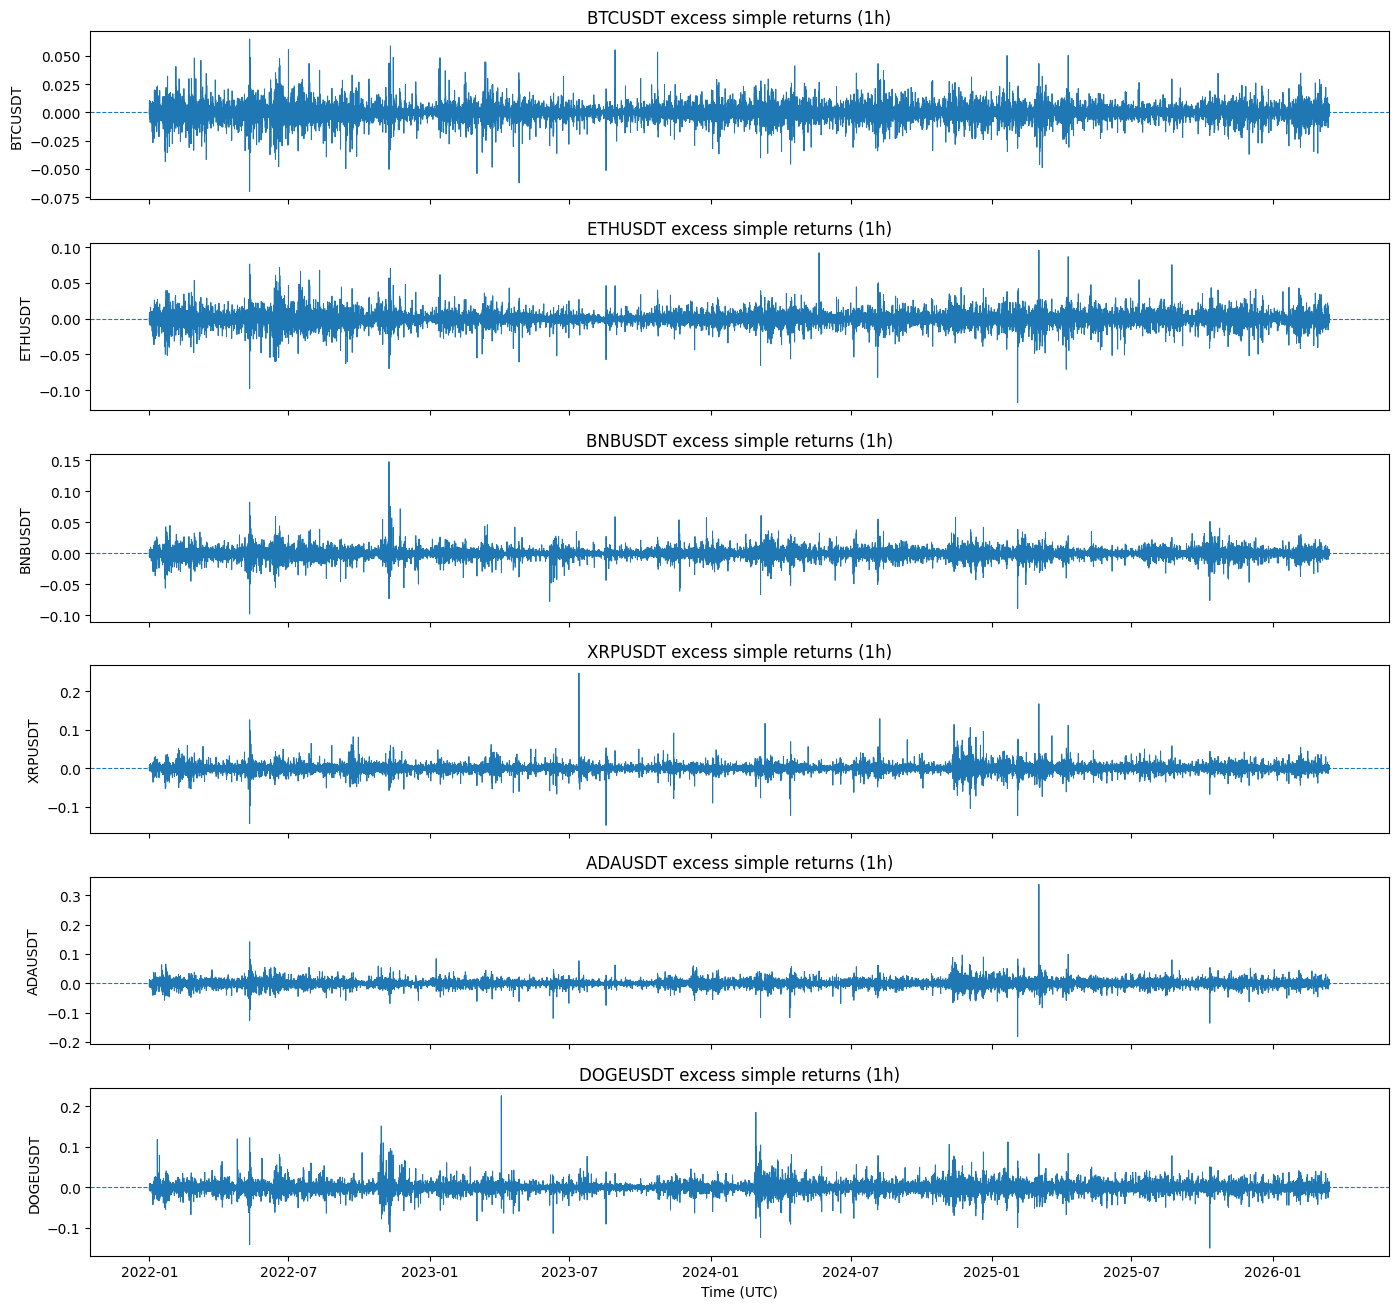

In [5]:
import os, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from IPython.display import display

# =========================
# ============================================================
# Part 1 
# ============================================================# =========================
SYMBOLS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT"]
INTERVAL = "1h"
START = pd.Timestamp("2022-01-01", tz="UTC")
END = pd.Timestamp.now(tz="UTC").floor("min")
RF_SERIES = "DFF"   # change to "EFFR" if needed
OUTDIR = Path("part1_binance_data")
MAKE_PLOTS = True

OUTDIR.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore", category=FutureWarning)

# =========================
# Helpers
# =========================
def interval_to_timedelta(interval: str) -> pd.Timedelta:
    n, unit = int(interval[:-1]), interval[-1]
    if unit == "m":
        return pd.Timedelta(minutes=n)
    if unit == "h":
        return pd.Timedelta(hours=n)
    if unit == "d":
        return pd.Timedelta(days=n)
    if unit == "w":
        return pd.Timedelta(weeks=n)
    raise ValueError(f"Unsupported interval for this notebook cell: {interval}")

def interval_to_freq(interval: str) -> str:
    n, unit = int(interval[:-1]), interval[-1]
    if unit == "m":
        return f"{n}min"
    if unit == "h":
        return f"{n}h"
    if unit == "d":
        return f"{n}D"
    if unit == "w":
        return f"{n}W"
    raise ValueError(f"Unsupported interval for this notebook cell: {interval}")

def make_session() -> requests.Session:
    retry = Retry(
        total=5,
        backoff_factor=0.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    s = requests.Session()
    s.mount("https://", HTTPAdapter(max_retries=retry))
    s.headers.update({"User-Agent": "Mozilla/5.0"})
    return s

def save_frame(df: pd.DataFrame, stem: str) -> Path:
    csv_path = OUTDIR / f"{stem}.csv"
    df.to_csv(csv_path, index=False)
    return csv_path

def fetch_binance_klines(symbol: str, interval: str, start: pd.Timestamp, end: pd.Timestamp, session: requests.Session) -> pd.DataFrame:
    url = "https://data-api.binance.vision/api/v3/klines"
    step_ms = int(interval_to_timedelta(interval).total_seconds() * 1000)
    start_ms = int(pd.Timestamp(start).timestamp() * 1000)
    end_ms = int(pd.Timestamp(end).timestamp() * 1000)

    all_rows = []
    current = start_ms
    while current < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current,
            "endTime": end_ms,
            "limit": 1000,
        }
        r = session.get(url, params=params, timeout=30)
        r.raise_for_status()
        rows = r.json()
        if not rows:
            break

        all_rows.extend(rows)
        last_open = rows[-1][0]
        next_current = last_open + step_ms
        if next_current <= current:
            next_current = current + step_ms
        current = next_current

        if len(rows) < 1000:
            break
        time.sleep(0.05)

    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "n_trades",
        "taker_buy_base", "taker_buy_quote", "ignore"
    ]
    df = pd.DataFrame(all_rows, columns=cols)
    if df.empty:
        raise ValueError(f"No Binance klines returned for {symbol}.")

    num_cols = ["open", "high", "low", "close", "volume", "quote_volume", "taker_buy_base", "taker_buy_quote"]
    int_cols = ["n_trades"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in int_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("int64")

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    df["symbol"] = symbol
    df = df[df["close_time"] < pd.Timestamp(end)]
    df = df.drop(columns=["ignore"]).sort_values("open_time").drop_duplicates(["symbol", "open_time"])
    return df

def repair_symbol_frame(df_symbol: pd.DataFrame, interval: str) -> pd.DataFrame:
    freq = interval_to_freq(interval)
    price_cols = ["open", "high", "low", "close"]
    vol_cols = ["volume", "quote_volume", "taker_buy_base", "taker_buy_quote"]
    cnt_cols = ["n_trades"]

    df = df_symbol.sort_values("open_time").drop_duplicates("open_time", keep="last").copy()
    full_index = pd.date_range(df["open_time"].min(), df["open_time"].max(), freq=freq, tz="UTC")
    df = df.set_index("open_time").reindex(full_index)
    df.index.name = "open_time"

    df["was_missing_bar"] = df["symbol"].isna()
    df["symbol"] = df["symbol"].ffill().bfill()

    for c in price_cols + vol_cols + cnt_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["close"] = df["close"].where(df["close"] > 0)
    df["close"] = df["close"].ffill().bfill()

    for c in ["open", "high", "low"]:
        df[c] = df[c].where(df[c] > 0, np.nan).fillna(df["close"])

    for c in vol_cols + cnt_cols:
        df[c] = df[c].fillna(0).clip(lower=0)

    px_block = df[["open", "high", "low", "close"]]
    df["high"] = px_block.max(axis=1)
    df["low"] = px_block.min(axis=1)

    df["was_repaired_spike"] = False
    logc = np.log(df["close"])
    prev_c = df["close"].shift(1)
    next_c = df["close"].shift(-1)

    abs_ret_med = np.nanmedian(np.abs(logc.diff()))
    if not np.isfinite(abs_ret_med) or abs_ret_med <= 0:
        abs_ret_med = np.log(1.001)

    jump_thr = max(10 * abs_ret_med, np.log(1.25))
    neighbor_thr = max(4 * abs_ret_med, np.log(1.03))

    in_jump = np.log(df["close"] / prev_c)
    out_jump = np.log(next_c / df["close"])
    neighbor_move = np.abs(np.log(next_c / prev_c))

    glitch = (
        prev_c.notna()
        & next_c.notna()
        & np.isfinite(in_jump)
        & np.isfinite(out_jump)
        & (np.sign(in_jump) != np.sign(out_jump))
        & (np.abs(in_jump) > jump_thr)
        & (np.abs(out_jump) > jump_thr)
        & (neighbor_move < neighbor_thr)
    )

    if glitch.any():
        repaired_close = np.exp((np.log(prev_c[glitch]) + np.log(next_c[glitch])) / 2.0)
        scale = repaired_close / df.loc[glitch, "close"]
        for c in price_cols:
            df.loc[glitch, c] = df.loc[glitch, c].values * scale.values
        px_block = df[["open", "high", "low", "close"]]
        df["high"] = px_block.max(axis=1)
        df["low"] = px_block.min(axis=1)
        df.loc[glitch, "was_repaired_spike"] = True

    bar_delta = interval_to_timedelta(interval)
    df["close_time"] = df.index + bar_delta - pd.Timedelta(milliseconds=1)

    out = df.reset_index()[[
        "symbol", "open_time", "close_time", "open", "high", "low", "close",
        "volume", "quote_volume", "n_trades", "taker_buy_base", "taker_buy_quote",
        "was_missing_bar", "was_repaired_spike"
    ]]
    return out

def fetch_fred_series(series_id: str, start: pd.Timestamp, end: pd.Timestamp, session: requests.Session) -> pd.DataFrame:
    start_s = pd.Timestamp(start).strftime("%Y-%m-%d")
    end_s = pd.Timestamp(end).strftime("%Y-%m-%d")
    api_key = os.getenv("FRED_API_KEY", "").strip()

    if api_key:
        url = "https://api.stlouisfed.org/fred/series/observations"
        params = {
            "series_id": series_id,
            "api_key": api_key,
            "file_type": "json",
            "observation_start": start_s,
            "observation_end": end_s,
        }
        r = session.get(url, params=params, timeout=30)
        r.raise_for_status()
        payload = r.json()
        obs = payload.get("observations", [])
        rf = pd.DataFrame(obs)[["date", "value"]]
    else:
        csv_url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        rf = pd.read_csv(csv_url)
        rf = rf.iloc[:, :2]
        rf.columns = ["date", "value"]
        rf = rf[(rf["date"] >= start_s) & (rf["date"] <= end_s)]

    rf["date"] = pd.to_datetime(rf["date"], utc=True)
    rf["value"] = pd.to_numeric(rf["value"], errors="coerce")
    rf = rf.dropna().sort_values("date").drop_duplicates("date").rename(columns={"value": "rf_annual_pct"})
    rf["rf_annual_decimal"] = rf["rf_annual_pct"] / 100.0
    return rf

# =========================
# Requirement checks
# =========================
if INTERVAL == "1d" and (END - START) < pd.Timedelta(days=1000):
    raise ValueError("For daily bars the project asks for at least 1000 observations. Extend START further back.")
if INTERVAL == "1m" and (END - START) < pd.Timedelta(days=14):
    raise ValueError("For 1-minute bars the project asks for at least 2 weeks of data. Extend START further back.")

# =========================
# Download raw Binance OHLCV
# =========================
session = make_session()

raw_list = []
for sym in SYMBOLS:
    print(f"Downloading {sym} {INTERVAL} bars from Binance ...")
    raw_list.append(fetch_binance_klines(sym, INTERVAL, START, END, session))

raw_ohlcv = pd.concat(raw_list, ignore_index=True).sort_values(["symbol", "open_time"]).reset_index(drop=True)

# =========================
# Clean and repair data
# =========================
clean_list = []
for sym, df_sym in raw_ohlcv.groupby("symbol", sort=False):
    clean_list.append(repair_symbol_frame(df_sym, INTERVAL))

clean_ohlcv = pd.concat(clean_list, ignore_index=True).sort_values(["symbol", "open_time"]).reset_index(drop=True)

# =========================
# Download risk-free series and align to crypto bars
# =========================
bar_index = pd.date_range(
    clean_ohlcv["open_time"].min(),
    clean_ohlcv["open_time"].max(),
    freq=interval_to_freq(INTERVAL),
    tz="UTC"
)

rf_daily = fetch_fred_series(RF_SERIES, START - pd.Timedelta(days=7), END + pd.Timedelta(days=7), session)
rf_daily["date_only"] = rf_daily["date"].dt.floor("D")
rf_daily = rf_daily.drop_duplicates("date_only").set_index("date_only").sort_index()

rf_aligned = pd.DataFrame(index=bar_index)
rf_aligned["date_only"] = rf_aligned.index.floor("D")
rf_aligned["rf_annual_decimal"] = rf_aligned["date_only"].map(rf_daily["rf_annual_decimal"])
rf_aligned["rf_annual_decimal"] = rf_aligned["rf_annual_decimal"].ffill().bfill()

interval_days = interval_to_timedelta(INTERVAL) / pd.Timedelta(days=1)
rf_aligned["rf_interval"] = rf_aligned["rf_annual_decimal"] * (interval_days / 365.0)
rf_aligned = rf_aligned.reset_index().rename(columns={"index": "open_time"})

# =========================
# Compute simple and excess simple returns
# =========================
returns = clean_ohlcv[["symbol", "open_time", "close"]].copy()
returns["simple_return"] = returns.groupby("symbol", sort=False)["close"].pct_change()
returns = returns.merge(rf_aligned[["open_time", "rf_interval"]], on="open_time", how="left")
returns["rf_lag1"] = returns.groupby("symbol", sort=False)["rf_interval"].shift(1)
returns["excess_simple_return"] = returns["simple_return"] - returns["rf_lag1"]

excess_returns_wide = returns.pivot(index="open_time", columns="symbol", values="excess_simple_return").sort_index()

# =========================
# Save outputs
# =========================
raw_path = save_frame(raw_ohlcv, f"raw_ohlcv_{INTERVAL}")
clean_path = save_frame(clean_ohlcv, f"clean_ohlcv_{INTERVAL}")
rf_path = save_frame(rf_aligned, f"risk_free_{RF_SERIES}_{INTERVAL}")
ret_path = save_frame(returns, f"returns_{INTERVAL}")

# =========================
# Summary / diagnostics
# =========================
obs_summary = (
    clean_ohlcv.groupby("symbol")
    .agg(
        n_bars=("open_time", "size"),
        first_bar=("open_time", "min"),
        last_bar=("open_time", "max"),
        inserted_missing_bars=("was_missing_bar", "sum"),
        repaired_spikes=("was_repaired_spike", "sum"),
    )
    .reset_index()
)

obs_summary_path = OUTDIR / f"obs_summary_{INTERVAL}.csv"
obs_summary.to_csv(obs_summary_path, index=False)

avg_abs_simple_bps = 1e4 * returns["simple_return"].abs().mean(skipna=True)
avg_rf_bps = 1e4 * returns["rf_lag1"].mean(skipna=True)
rf_share_pct = 100 * avg_rf_bps / avg_abs_simple_bps if avg_abs_simple_bps and np.isfinite(avg_abs_simple_bps) else np.nan

summary_text = f"""
Saved files:
  raw   -> {raw_path}
  clean -> {clean_path}
  rf    -> {rf_path}
  rets  -> {ret_path}
  obs   -> {obs_summary_path}

Why the risk-free term is often ignorable at mid/high frequency:
  Average |simple return| per {INTERVAL} bar  : {avg_abs_simple_bps:.4f} bps
  Average lagged risk-free per {INTERVAL} bar : {avg_rf_bps:.6f} bps
  RF as % of avg |bar return|                 : {rf_share_pct:.4f}%
  Interpretation: the fed-funds contribution per bar is usually orders of magnitude smaller
  than crypto bar-to-bar price moves, so excess and raw simple returns are nearly identical intraday.
""".strip()

print("\n" + summary_text)

text_path = OUTDIR / f"summary_{INTERVAL}.txt"
text_path.write_text(summary_text, encoding="utf-8")

display(obs_summary)

# =========================
# Plot return time series
# =========================
if MAKE_PLOTS:
    fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(14, 2.2 * len(SYMBOLS)), sharex=True)
    if len(SYMBOLS) == 1:
        axes = [axes]

    for ax, sym in zip(axes, SYMBOLS):
        s = excess_returns_wide[sym].dropna()
        ax.plot(s.index, s.values, linewidth=0.7)
        ax.axhline(0.0, linewidth=0.8, linestyle="--")
        ax.set_ylabel(sym)
        ax.set_title(f"{sym} excess simple returns ({INTERVAL})")

    plt.xlabel("Time (UTC)")
    plt.tight_layout()

    plot_path = OUTDIR / f"excess_returns_{INTERVAL}.png"
    fig.savefig(plot_path, dpi=300, bbox_inches="tight")

    plt.show()

Universe: ADAUSDT, BNBUSDT, BTCUSDT, DOGEUSDT, ETHUSDT, XRPUSDT
Sample: 2022-01-01 00:00:00+00:00  ->  2026-03-15 15:00:00+00:00   |   bars=36,832
Initial capital: 10,000 USDT
Gross cap:       100,000 USDT

Split:
  Train: 2022-01-15 02:00:00+00:00  ->  2024-07-15 09:00:00+00:00
  Valid: 2024-07-15 10:00:00+00:00  ->  2025-05-15 12:00:00+00:00
  Test : 2025-05-15 13:00:00+00:00   ->  2026-03-15 15:00:00+00:00

Saved:
  positions   -> part2_strategies/strategy_positions_1h.csv
  ts          -> part2_strategies/strategy_timeseries_1h.csv
  summary     -> part2_strategies/strategy_summary_1h.csv
  search      -> part2_strategies/strategy_param_search_1h.csv
  trend_top5  -> part2_strategies/trend_top5_1h.csv
  mr_top5     -> part2_strategies/mean_reversion_top5_1h.csv

Top trend-following candidates (selected on validation Sharpe):
Top mean-reversion candidates (selected on validation Sharpe):
Locked-parameter summary:


,strategy,lookback_bars,turnover_penalty,valid_sharpe,valid_ann_mean,valid_ann_vol,valid_cum_pnl_usdt,valid_avg_gross_exposure_usdt,valid_avg_turnover_usdt
0,trend_following,336,0.02,2.522506,26.790115,10.620437,223220.377214,100000.000000,2533.371996
1,trend_following,336,0.05,2.453835,26.006689,10.598386,216692.719470,100000.000000,1855.208657
2,trend_following,336,0.10,2.323651,24.371099,10.488280,203064.667516,99998.691592,1453.842467
3,trend_following,168,0.02,1.741618,18.068021,10.374274,150546.219442,100000.000000,4014.869710
4,trend_following,24,0.05,1.355885,14.329734,10.568543,119398.092124,99613.102048,11049.175181


,strategy,lookback_bars,turnover_penalty,valid_sharpe,valid_ann_mean,valid_ann_vol,valid_cum_pnl_usdt,valid_avg_gross_exposure_usdt,valid_avg_turnover_usdt
0,mean_reversion,24,0.10,-1.207123,-8.297442,6.873733,-69135.874352,98988.246182,7460.502211
1,mean_reversion,4,0.02,-1.611577,-10.021358,6.218354,-83499.878641,98392.380072,37473.219686
2,mean_reversion,24,0.05,-1.861791,-13.737947,7.378888,-114467.208191,99639.914100,9819.793865
3,mean_reversion,12,0.10,-2.000407,-11.966369,5.981967,-99706.081180,96859.651032,9747.537149
4,mean_reversion,8,0.10,-2.111303,-11.444276,5.420480,-95355.900977,94589.372318,10959.516677


,strategy,selected_lookback_bars,selected_turnover_penalty,risk_aversion,cov_shrink,vol_cov_window_bars,validation_sharpe,validation_cum_pnl_usdt,validation_avg_gross_exposure_usdt,validation_avg_turnover_usdt,test_sharpe,test_cum_pnl_usdt,test_avg_gross_exposure_usdt,test_avg_turnover_usdt
0,trend_following,336,0.02,15.0,0.25,168,2.522506,223220.377214,100000.000000,2533.371996,0.342979,21368.559317,99998.751369,2522.636059
1,mean_reversion,24,0.10,15.0,0.25,168,-1.207123,-69135.874352,98988.246182,7460.502211,0.622691,17714.805349,98323.455224,6246.839169


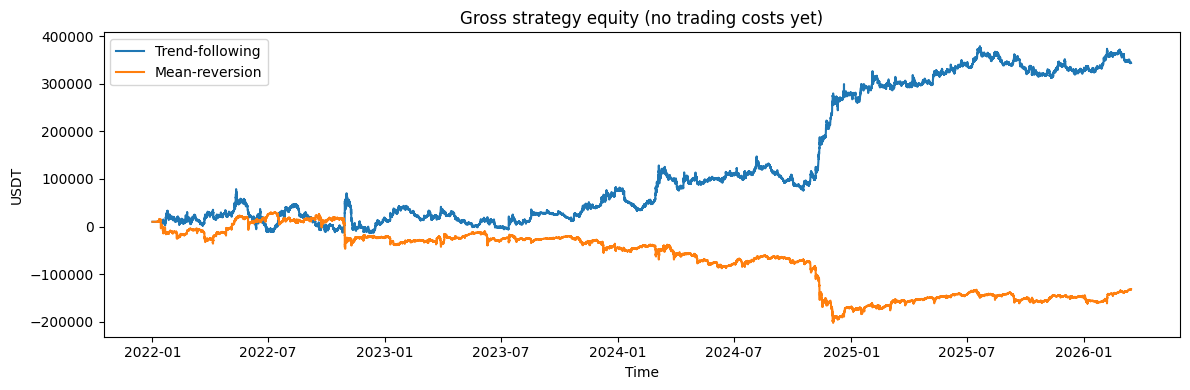

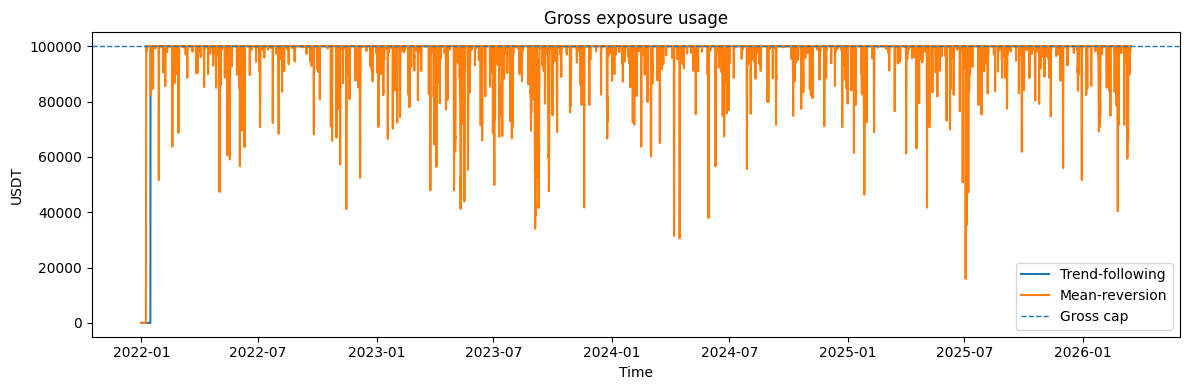

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ============================================================
# Part 2 — Two strategies + cost-aware exposure sizing
# ============================================================

# ----------------------------
# User config
# ----------------------------
INTERVAL = "1h"                      # should match Part 1 output
DATA_DIR = Path("part1_binance_data")
OUTDIR = Path("part2_strategies")
OUTDIR.mkdir(parents=True, exist_ok=True)

STARTING_CAPITAL = 10_000.0
GROSS_CAP = 100_000.0               # fixed cap from assignment (= 10x initial capital)

VOL_COV_WIN = 168                   # 1 week on 1h bars
RISK_AVERSION = 15.0                # fixed to avoid overfitting
COV_SHRINK = 0.25                   # diagonal shrinkage for covariance stability

TRAIN_FRAC = 0.60
VALID_FRAC = 0.20                   # final 20% acts as out-of-sample test

TREND_LOOKBACK_GRID = [24, 72, 168, 336]
MR_LOOKBACK_GRID = [4, 8, 12, 24]
TURNOVER_PENALTY_GRID = [0.02, 0.05, 0.10]  # tuned; smaller = more reactive, larger = smoother

MAKE_PLOTS = True

# ----------------------------
# Helpers
# ----------------------------
def interval_to_timedelta(interval: str) -> pd.Timedelta:
    n, unit = int(interval[:-1]), interval[-1]
    if unit == "m":
        return pd.Timedelta(minutes=n)
    if unit == "h":
        return pd.Timedelta(hours=n)
    if unit == "d":
        return pd.Timedelta(days=n)
    if unit == "w":
        return pd.Timedelta(weeks=n)
    raise ValueError(f"Unsupported interval: {interval}")

def bars_per_year(interval: str) -> float:
    return pd.Timedelta(days=365) / interval_to_timedelta(interval)

BARS_PER_YEAR = float(bars_per_year(INTERVAL))

def safe_save(df: pd.DataFrame, stem: str):
    csv = OUTDIR / f"{stem}.csv"
    df.to_csv(csv, index=False)
    return csv

def load_saved_frame(stem: str, interval: str) -> pd.DataFrame:
    csv = DATA_DIR / f"{stem}_{interval}.csv"
    pq = DATA_DIR / f"{stem}_{interval}.parquet"
    h5 = DATA_DIR / f"{stem}_{interval}.h5"
    if csv.exists():
        df = pd.read_csv(csv)
    elif pq.exists():
        df = pd.read_parquet(pq)
    elif h5.exists():
        df = pd.read_hdf(h5, key="data")
    else:
        raise FileNotFoundError(
            f"Could not find {csv.name}, {pq.name} or {h5.name}. Run Part 1 first or keep clean_ohlcv in memory."
        )
    for c in df.columns:
        if "time" in c.lower() or c.lower() == "date":
            try:
                df[c] = pd.to_datetime(df[c], utc=True)
            except Exception:
                pass
    return df

def project_l1_ball(v: np.ndarray, z: float = 1.0) -> np.ndarray:
    """Project v onto {x: ||x||_1 <= z}."""
    v = np.asarray(v, dtype=float)
    if z <= 0:
        return np.zeros_like(v)
    if np.sum(np.abs(v)) <= z:
        return v.copy()
    u = np.sort(np.abs(v))[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u) + 1) > (cssv - z))[0][-1]
    theta = (cssv[rho] - z) / (rho + 1.0)
    w = np.sign(v) * np.maximum(np.abs(v) - theta, 0.0)
    return w

def ann_sharpe(x: pd.Series, bars_per_year: float) -> float:
    x = pd.Series(x).dropna()
    sd = float(x.std(ddof=0))
    if len(x) < 10 or sd == 0 or not np.isfinite(sd):
        return np.nan
    return np.sqrt(bars_per_year) * float(x.mean()) / sd

def perf_slice(bt: dict, start: int, stop: int, bars_per_year: float) -> dict:
    r = bt["ret_on_initial_capital"].iloc[start:stop].dropna()
    pnl = bt["pnl_usdt"].iloc[start:stop]
    gross = bt["gross_exposure_usdt"].iloc[start:stop]
    turn = bt["turnover_usdt"].iloc[start:stop]
    if len(r) == 0:
        return {
            "sharpe": np.nan,
            "ann_mean": np.nan,
            "ann_vol": np.nan,
            "cum_pnl_usdt": np.nan,
            "avg_gross_exposure_usdt": np.nan,
            "avg_turnover_usdt": np.nan,
        }
    return {
        "sharpe": ann_sharpe(r, bars_per_year),
        "ann_mean": bars_per_year * float(r.mean()),
        "ann_vol": np.sqrt(bars_per_year) * float(r.std(ddof=0)),
        "cum_pnl_usdt": float(pnl.sum()),
        "avg_gross_exposure_usdt": float(gross.mean()),
        "avg_turnover_usdt": float(turn.mean()),
    }

def build_cov_stack(ret_df: pd.DataFrame, win: int = 168, shrink: float = 0.25) -> np.ndarray:
    """Precompute rolling shrunk covariance matrices S_t using returns up to t-1."""
    R = ret_df.to_numpy(dtype=float)
    T, N = R.shape
    covs = np.full((T, N, N), np.nan, dtype=float)
    min_obs = max(40, N + 5)
    for t in range(win, T):
        X = R[t - win:t]  # uses only past returns
        X = X[np.isfinite(X).all(axis=1)]
        if X.shape[0] < min_obs:
            continue
        S = np.cov(X, rowvar=False)
        if not np.all(np.isfinite(S)):
            continue
        D = np.diag(np.diag(S))
        S = (1.0 - shrink) * S + shrink * D + 1e-8 * np.eye(N)
        covs[t] = S
    return covs

def make_trend_mu(close_df: pd.DataFrame, sigma1_df: pd.DataFrame, lookback: int) -> pd.DataFrame:
    """
    Trend-following / time-series momentum:
    signal_t ~ tanh( log(P_t / P_{t-L}) / (sigma_t * sqrt(L)) )
    Then shift by 1 bar to avoid lookahead and map to expected-return units using sigma1.
    """
    mom = np.log(close_df / close_df.shift(lookback))
    z = mom / (sigma1_df * np.sqrt(lookback) + 1e-12)
    signal = np.tanh(z).shift(1)
    mu = signal * sigma1_df
    return mu

def make_meanrev_mu(close_df: pd.DataFrame, sigma1_df: pd.DataFrame, lookback: int) -> pd.DataFrame:
    """
    Cross-sectional short-term mean-reversion:
    take L-bar log return, de-mean cross-sectionally, fade recent winners/losers.
    signal_t ~ -tanh( cs_demeaned_return / (sigma_t * sqrt(L)) )
    """
    short = np.log(close_df / close_df.shift(lookback))
    cs = short.sub(short.mean(axis=1), axis=0)
    z = cs / (sigma1_df * np.sqrt(lookback) + 1e-12)
    signal = -np.tanh(z).shift(1)
    mu = signal * sigma1_df
    return mu

def run_strategy(
    mu_df: pd.DataFrame,
    ret_df: pd.DataFrame,
    cov_stack: np.ndarray,
    gross_cap: float,
    initial_capital: float,
    risk_aversion: float,
    turnover_penalty: float,
    neutral: bool = False,
) -> dict:
    """
    Solve each bar:
        max_w mu'w - 0.5*lambda*w'Sw - 0.5*kappa||w - w_prev||^2
        s.t. ||w||_1 <= 1
    with theta = gross_cap * w.
    """
    idx = ret_df.index
    cols = ret_df.columns
    R = ret_df.to_numpy(dtype=float)
    MU = mu_df.reindex_like(ret_df).to_numpy(dtype=float)

    T, N = R.shape
    W = np.zeros((T, N), dtype=float)
    pnl = np.zeros(T, dtype=float)
    gross = np.zeros(T, dtype=float)
    turnover = np.zeros(T, dtype=float)

    w_prev = np.zeros(N, dtype=float)

    for t in range(T):
        mu_t = MU[t].copy()
        S_t = cov_stack[t]

        if not np.isfinite(S_t).any():
            w_t = np.zeros(N, dtype=float)
        else:
            diag = np.diag(S_t)
            valid = np.isfinite(mu_t) & np.isfinite(diag) & (diag > 0)
            if valid.sum() == 0:
                w_t = np.zeros(N, dtype=float)
            else:
                mu_v = mu_t[valid].copy()
                S_v = np.nan_to_num(S_t[np.ix_(valid, valid)], nan=0.0)
                if neutral and valid.sum() > 1:
                    mu_v = mu_v - np.mean(mu_v)

                A = risk_aversion * S_v + turnover_penalty * np.eye(valid.sum())
                b = mu_v + turnover_penalty * w_prev[valid]

                try:
                    w_v = np.linalg.solve(A, b)
                except np.linalg.LinAlgError:
                    w_v = np.linalg.lstsq(A, b, rcond=None)[0]

                w_t = np.zeros(N, dtype=float)
                w_t[valid] = w_v
                w_t = project_l1_ball(w_t, z=1.0)

        W[t] = w_t
        pnl[t] = gross_cap * np.nansum(w_t * R[t])              # PnL in USDT on fixed gross cap
        gross[t] = gross_cap * np.nansum(np.abs(w_t))           # should be <= 100,000
        turnover[t] = gross_cap * np.nansum(np.abs(w_t - w_prev))
        w_prev = w_t.copy()

    weights = pd.DataFrame(W, index=idx, columns=cols)
    theta = gross_cap * weights

    assert np.all(theta.abs().sum(axis=1).fillna(0.0).values <= gross_cap + 1e-6), "Gross cap violated."

    ts = pd.DataFrame({
        "open_time": idx,
        "pnl_usdt": pnl,
        "ret_on_initial_capital": pnl / initial_capital,
        "gross_exposure_usdt": gross,
        "turnover_usdt": turnover,
        "cum_pnl_usdt": np.cumsum(pnl),
        "equity_gross_no_costs": initial_capital + np.cumsum(pnl),
    }).set_index("open_time")

    return {"weights": weights, "theta": theta, "timeseries": ts, "pnl_usdt": ts["pnl_usdt"],
            "ret_on_initial_capital": ts["ret_on_initial_capital"],
            "gross_exposure_usdt": ts["gross_exposure_usdt"],
            "turnover_usdt": ts["turnover_usdt"]}

def stack_theta(theta_df: pd.DataFrame, strategy_name: str) -> pd.DataFrame:
    out = theta_df.stack().rename("theta_usdt").reset_index()
    out.columns = ["open_time", "symbol", "theta_usdt"]
    out["weight_on_gross_cap"] = out["theta_usdt"] / GROSS_CAP
    out["strategy"] = strategy_name
    return out[["strategy", "open_time", "symbol", "theta_usdt", "weight_on_gross_cap"]]

# ----------------------------
# Load cleaned OHLCV from Part 1
# ----------------------------
if "clean_ohlcv" in globals() and isinstance(clean_ohlcv, pd.DataFrame):
    clean_df = clean_ohlcv.copy()
else:
    clean_df = load_saved_frame("clean_ohlcv", INTERVAL)

for c in ["open_time", "close_time"]:
    if c in clean_df.columns:
        clean_df[c] = pd.to_datetime(clean_df[c], utc=True)

num_cols = ["open", "high", "low", "close", "volume", "quote_volume", "taker_buy_base", "taker_buy_quote"]
for c in num_cols:
    if c in clean_df.columns:
        clean_df[c] = pd.to_numeric(clean_df[c], errors="coerce")

close_wide = (
    clean_df.pivot(index="open_time", columns="symbol", values="close")
    .sort_index()
    .astype(float)
    .ffill()
)

ret_wide = close_wide.pct_change()

symbols = list(close_wide.columns)
T, N = ret_wide.shape
if N < 2:
    raise ValueError("Need at least two assets for the requested Part 2 implementation.")

# ----------------------------
# Volatility and covariance estimates
# ----------------------------
sigma1 = ret_wide.rolling(VOL_COV_WIN).std().shift(1)  # 1-bar vol estimate known at time t
cov_stack = build_cov_stack(ret_wide, win=VOL_COV_WIN, shrink=COV_SHRINK)

# ----------------------------
# Train / validation / test split
# ----------------------------
usable_start = max(VOL_COV_WIN + 2, max(TREND_LOOKBACK_GRID) + 2, max(MR_LOOKBACK_GRID) + 2)
usable_len = T - usable_start
if usable_len < 200:
    raise ValueError("Sample is too short after warm-up for a train/validation/test split.")

train_end = usable_start + int(TRAIN_FRAC * usable_len)
valid_end = usable_start + int((TRAIN_FRAC + VALID_FRAC) * usable_len)

train_start_time = ret_wide.index[usable_start]
train_end_time = ret_wide.index[train_end - 1]
valid_start_time = ret_wide.index[train_end]
valid_end_time = ret_wide.index[valid_end - 1]
test_start_time = ret_wide.index[valid_end]
test_end_time = ret_wide.index[-1]

# ----------------------------
# Parameter search: Trend-following
# ----------------------------
trend_search_rows = []
for lb in TREND_LOOKBACK_GRID:
    mu = make_trend_mu(close_wide, sigma1, lb)
    for kappa in TURNOVER_PENALTY_GRID:
        bt = run_strategy(
            mu_df=mu,
            ret_df=ret_wide,
            cov_stack=cov_stack,
            gross_cap=GROSS_CAP,
            initial_capital=STARTING_CAPITAL,
            risk_aversion=RISK_AVERSION,
            turnover_penalty=kappa,
            neutral=False,
        )
        val_stats = perf_slice(bt, train_end, valid_end, BARS_PER_YEAR)
        trend_search_rows.append({
            "strategy": "trend_following",
            "lookback_bars": lb,
            "turnover_penalty": kappa,
            "valid_sharpe": val_stats["sharpe"],
            "valid_ann_mean": val_stats["ann_mean"],
            "valid_ann_vol": val_stats["ann_vol"],
            "valid_cum_pnl_usdt": val_stats["cum_pnl_usdt"],
            "valid_avg_gross_exposure_usdt": val_stats["avg_gross_exposure_usdt"],
            "valid_avg_turnover_usdt": val_stats["avg_turnover_usdt"],
        })

trend_search = pd.DataFrame(trend_search_rows).sort_values(
    ["valid_sharpe", "valid_cum_pnl_usdt"], ascending=[False, False]
).reset_index(drop=True)

best_trend_lb = int(trend_search.loc[0, "lookback_bars"])
best_trend_kappa = float(trend_search.loc[0, "turnover_penalty"])

# ----------------------------
# Parameter search: Mean-reversion
# ----------------------------
mr_search_rows = []
for lb in MR_LOOKBACK_GRID:
    mu = make_meanrev_mu(close_wide, sigma1, lb)
    for kappa in TURNOVER_PENALTY_GRID:
        bt = run_strategy(
            mu_df=mu,
            ret_df=ret_wide,
            cov_stack=cov_stack,
            gross_cap=GROSS_CAP,
            initial_capital=STARTING_CAPITAL,
            risk_aversion=RISK_AVERSION,
            turnover_penalty=kappa,
            neutral=True,
        )
        val_stats = perf_slice(bt, train_end, valid_end, BARS_PER_YEAR)
        mr_search_rows.append({
            "strategy": "mean_reversion",
            "lookback_bars": lb,
            "turnover_penalty": kappa,
            "valid_sharpe": val_stats["sharpe"],
            "valid_ann_mean": val_stats["ann_mean"],
            "valid_ann_vol": val_stats["ann_vol"],
            "valid_cum_pnl_usdt": val_stats["cum_pnl_usdt"],
            "valid_avg_gross_exposure_usdt": val_stats["avg_gross_exposure_usdt"],
            "valid_avg_turnover_usdt": val_stats["avg_turnover_usdt"],
        })

mr_search = pd.DataFrame(mr_search_rows).sort_values(
    ["valid_sharpe", "valid_cum_pnl_usdt"], ascending=[False, False]
).reset_index(drop=True)

best_mr_lb = int(mr_search.loc[0, "lookback_bars"])
best_mr_kappa = float(mr_search.loc[0, "turnover_penalty"])

# ----------------------------
# Final full-sample runs with locked parameters
# ----------------------------
trend_mu = make_trend_mu(close_wide, sigma1, best_trend_lb)
trend_bt = run_strategy(
    mu_df=trend_mu,
    ret_df=ret_wide,
    cov_stack=cov_stack,
    gross_cap=GROSS_CAP,
    initial_capital=STARTING_CAPITAL,
    risk_aversion=RISK_AVERSION,
    turnover_penalty=best_trend_kappa,
    neutral=False,
)

mr_mu = make_meanrev_mu(close_wide, sigma1, best_mr_lb)
mr_bt = run_strategy(
    mu_df=mr_mu,
    ret_df=ret_wide,
    cov_stack=cov_stack,
    gross_cap=GROSS_CAP,
    initial_capital=STARTING_CAPITAL,
    risk_aversion=RISK_AVERSION,
    turnover_penalty=best_mr_kappa,
    neutral=True,
)

# ----------------------------
# Summaries
# ----------------------------
trend_valid = perf_slice(trend_bt, train_end, valid_end, BARS_PER_YEAR)
trend_test = perf_slice(trend_bt, valid_end, T, BARS_PER_YEAR)

mr_valid = perf_slice(mr_bt, train_end, valid_end, BARS_PER_YEAR)
mr_test = perf_slice(mr_bt, valid_end, T, BARS_PER_YEAR)

summary = pd.DataFrame([
    {
        "strategy": "trend_following",
        "selected_lookback_bars": best_trend_lb,
        "selected_turnover_penalty": best_trend_kappa,
        "risk_aversion": RISK_AVERSION,
        "cov_shrink": COV_SHRINK,
        "vol_cov_window_bars": VOL_COV_WIN,
        "validation_sharpe": trend_valid["sharpe"],
        "validation_cum_pnl_usdt": trend_valid["cum_pnl_usdt"],
        "validation_avg_gross_exposure_usdt": trend_valid["avg_gross_exposure_usdt"],
        "validation_avg_turnover_usdt": trend_valid["avg_turnover_usdt"],
        "test_sharpe": trend_test["sharpe"],
        "test_cum_pnl_usdt": trend_test["cum_pnl_usdt"],
        "test_avg_gross_exposure_usdt": trend_test["avg_gross_exposure_usdt"],
        "test_avg_turnover_usdt": trend_test["avg_turnover_usdt"],
    },
    {
        "strategy": "mean_reversion",
        "selected_lookback_bars": best_mr_lb,
        "selected_turnover_penalty": best_mr_kappa,
        "risk_aversion": RISK_AVERSION,
        "cov_shrink": COV_SHRINK,
        "vol_cov_window_bars": VOL_COV_WIN,
        "validation_sharpe": mr_valid["sharpe"],
        "validation_cum_pnl_usdt": mr_valid["cum_pnl_usdt"],
        "validation_avg_gross_exposure_usdt": mr_valid["avg_gross_exposure_usdt"],
        "validation_avg_turnover_usdt": mr_valid["avg_turnover_usdt"],
        "test_sharpe": mr_test["sharpe"],
        "test_cum_pnl_usdt": mr_test["cum_pnl_usdt"],
        "test_avg_gross_exposure_usdt": mr_test["avg_gross_exposure_usdt"],
        "test_avg_turnover_usdt": mr_test["avg_turnover_usdt"],
    }
])

# ----------------------------
# Save theta_t and time series
# ----------------------------
trend_theta_long = stack_theta(trend_bt["theta"], "trend_following")
mr_theta_long = stack_theta(mr_bt["theta"], "mean_reversion")
strategy_positions = pd.concat([trend_theta_long, mr_theta_long], ignore_index=True)

strategy_ts = pd.concat([
    trend_bt["timeseries"].reset_index().assign(strategy="trend_following"),
    mr_bt["timeseries"].reset_index().assign(strategy="mean_reversion")
], ignore_index=True)

search_table = pd.concat([trend_search.assign(search_group="trend"), mr_search.assign(search_group="mean_reversion")], ignore_index=True)

positions_path = safe_save(strategy_positions, f"strategy_positions_{INTERVAL}")
ts_path = safe_save(strategy_ts, f"strategy_timeseries_{INTERVAL}")
summary_path = safe_save(summary, f"strategy_summary_{INTERVAL}")
search_path = safe_save(search_table, f"strategy_param_search_{INTERVAL}")

trend_top5 = trend_search.head(5)
mr_top5 = mr_search.head(5)
trend_top5_path = safe_save(trend_top5, f"trend_top5_{INTERVAL}")
mr_top5_path = safe_save(mr_top5, f"mean_reversion_top5_{INTERVAL}")

# ----------------------------
# Display key outputs
# ----------------------------
output_text = "\n".join([
    f"Universe: {', '.join(symbols)}",
    f"Sample: {close_wide.index.min()}  ->  {close_wide.index.max()}   |   bars={len(close_wide):,}",
    f"Initial capital: {STARTING_CAPITAL:,.0f} USDT",
    f"Gross cap:       {GROSS_CAP:,.0f} USDT",
    "",
    "Split:",
    f"  Train: {train_start_time}  ->  {train_end_time}",
    f"  Valid: {valid_start_time}  ->  {valid_end_time}",
    f"  Test : {test_start_time}   ->  {test_end_time}",
    "",
    "Saved:",
    f"  positions   -> {positions_path}",
    f"  ts          -> {ts_path}",
    f"  summary     -> {summary_path}",
    f"  search      -> {search_path}",
    f"  trend_top5  -> {trend_top5_path}",
    f"  mr_top5     -> {mr_top5_path}",
    "",
    "Top trend-following candidates (selected on validation Sharpe):",
    "Top mean-reversion candidates (selected on validation Sharpe):",
    "Locked-parameter summary:",
])

print(output_text)

text_output_path = OUTDIR / f"run_output_{INTERVAL}.txt"
text_output_path.write_text(output_text, encoding="utf-8")

display(trend_top5)
display(mr_top5)
display(summary)

# ----------------------------
# Optional plots
# ----------------------------
if MAKE_PLOTS:
    trend_ts = trend_bt["timeseries"]
    mr_ts = mr_bt["timeseries"]

    fig1 = plt.figure(figsize=(12, 4))
    plt.plot(trend_ts.index, trend_ts["equity_gross_no_costs"], label="Trend-following")
    plt.plot(mr_ts.index, mr_ts["equity_gross_no_costs"], label="Mean-reversion")
    plt.title("Gross strategy equity (no trading costs yet)")
    plt.ylabel("USDT")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    fig1.savefig(OUTDIR / f"gross_strategy_equity_{INTERVAL}.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig2 = plt.figure(figsize=(12, 4))
    plt.plot(trend_ts.index, trend_ts["gross_exposure_usdt"], label="Trend-following")
    plt.plot(mr_ts.index, mr_ts["gross_exposure_usdt"], label="Mean-reversion")
    plt.axhline(GROSS_CAP, linestyle="--", linewidth=1.0, label="Gross cap")
    plt.title("Gross exposure usage")
    plt.ylabel("USDT")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    fig2.savefig(OUTDIR / f"gross_exposure_usage_{INTERVAL}.png", dpi=300, bbox_inches="tight")
    plt.show()

Loaded symbols: ADAUSDT, BNBUSDT, BTCUSDT, DOGEUSDT, ETHUSDT, XRPUSDT
Loaded strategies: mean_reversion, trend_following
Rolling window used for robust slippage medians: 720 bars

Chosen scalar slippage for Part 4:
  s = 0.00086777 decimal per trade = 8.6777 bps one-way

Saved:
  asset summary        -> part3_transaction_costs/slippage_asset_summary_1h.csv
  scalar summary       -> part3_transaction_costs/slippage_scalar_summary_1h.csv
  slippage series      -> part3_transaction_costs/slippage_series_1h.csv
  sensitivity summary  -> part3_transaction_costs/slippage_sensitivity_summary_1h.csv
  sensitivity ts       -> part3_transaction_costs/slippage_sensitivity_timeseries_1h.csv

Asset-level slippage estimates:
Scalar s summaries:
Strategy sensitivity to slippage:


,symbol,roll_cov_full_price_change,roll_half_spread_price_full,roll_slippage_decimal_full,roll_slippage_decimal_median_rolling,cs_slippage_decimal_median,selected_slippage_decimal,selected_slippage_bps,selected_method,median_close,avg_quote_volume
0,BNBUSDT,2.991788e-02,0.000000,0.000000,0.000523,0.000650,0.000523,5.234218,Roll,432.200000,8.994711e+06
1,BTCUSDT,-1.311764e+03,36.218285,0.000766,0.000597,0.000512,0.000597,5.965289,Roll,47274.560000,1.049323e+08
2,ETHUSDT,5.367110e-01,0.000000,0.000000,0.000000,0.000692,0.000692,6.923680,Corwin-Schultz fallback,2413.645000,5.125722e+07
3,ADAUSDT,-3.942722e-08,0.000199,0.000432,0.000906,0.001039,0.000906,9.064483,Roll,0.459500,4.075954e+06
4,XRPUSDT,-2.356353e-06,0.001535,0.002573,0.001041,0.000867,0.001041,10.406778,Roll,0.596700,1.294580e+07
5,DOGEUSDT,-9.180690e-08,0.000303,0.002708,0.001158,0.001017,0.001158,11.581076,Roll,0.111885,9.552443e+06


,scope,s_decimal,s_bps
0,global_all_strategies_turnover_weighted,0.000868,8.677690
1,mean_reversion_turnover_weighted,0.000851,8.505087
2,trend_following_turnover_weighted,0.000908,9.083630
3,cross_asset_median,0.000799,7.994081


,strategy,s_multiplier,s_used_decimal,s_used_bps,gross_pnl_usdt,cost_usdt,net_pnl_usdt,total_turnover_usdt,avg_turnover_per_bar_usdt,strategy_trade_weighted_s_decimal,strategy_trade_weighted_s_bps,cost_as_pct_of_abs_gross_pnl
0,mean_reversion,0.0,0.000000,0.000000,-141850.666095,0.000000,-141850.666095,2.450632e+08,6653.540247,0.000851,8.505087,0.000000
1,mean_reversion,0.5,0.000434,4.338845,-141850.666095,106329.122411,-248179.788506,2.450632e+08,6653.540247,0.000851,8.505087,74.958494
2,mean_reversion,1.0,0.000868,8.677690,-141850.666095,212658.244822,-354508.910917,2.450632e+08,6653.540247,0.000851,8.505087,149.916987
3,mean_reversion,1.5,0.001302,13.016535,-141850.666095,318987.367232,-460838.033328,2.450632e+08,6653.540247,0.000851,8.505087,224.875481
4,mean_reversion,2.0,0.001736,17.355380,-141850.666095,425316.489643,-567167.155738,2.450632e+08,6653.540247,0.000851,8.505087,299.833974
5,mean_reversion,3.0,0.002603,26.033070,-141850.666095,637974.734465,-779825.400560,2.450632e+08,6653.540247,0.000851,8.505087,449.750961
6,trend_following,0.0,0.000000,0.000000,333853.022778,0.000000,333853.022778,1.041990e+08,2829.033921,0.000908,9.083630,0.000000
7,trend_following,0.5,0.000434,4.338845,333853.022778,45210.321560,288642.701219,1.041990e+08,2829.033921,0.000908,9.083630,13.541984
8,trend_following,1.0,0.000868,8.677690,333853.022778,90420.643119,243432.379659,1.041990e+08,2829.033921,0.000908,9.083630,27.083967
9,trend_following,1.5,0.001302,13.016535,333853.022778,135630.964679,198222.058099,1.041990e+08,2829.033921,0.000908,9.083630,40.625951


Interpretation at 1.0x estimated slippage:
  mean_reversion: gross PnL = -141850.67 USDT, cost drag = 212658.24 USDT, net PnL = -354508.91 USDT, cost drag = 149.92% of |gross PnL|.
  trend_following: gross PnL = 333853.02 USDT, cost drag = 90420.64 USDT, net PnL = 243432.38 USDT, cost drag = 27.08% of |gross PnL|.
  More turnover-intensive strategy under this estimate: mean_reversion


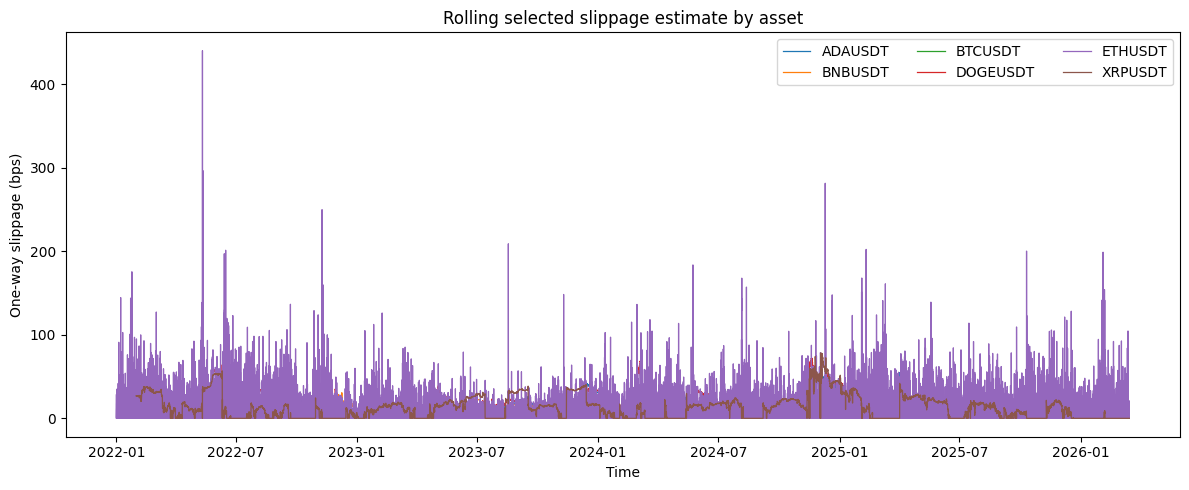

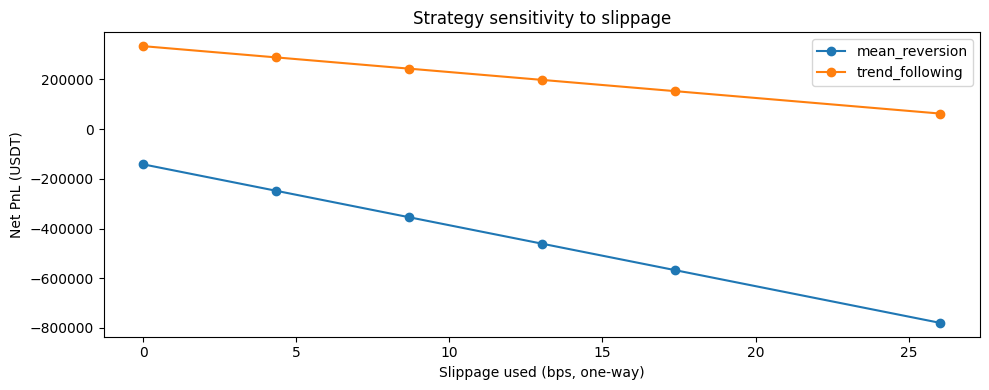

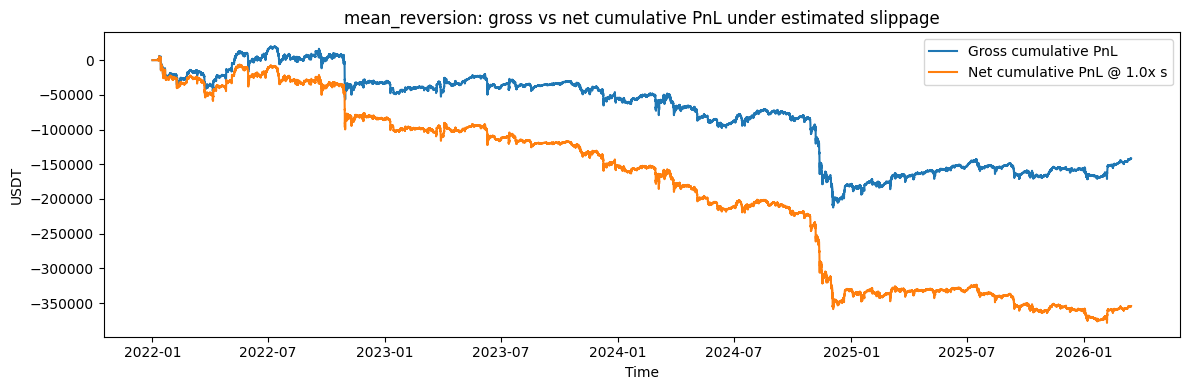

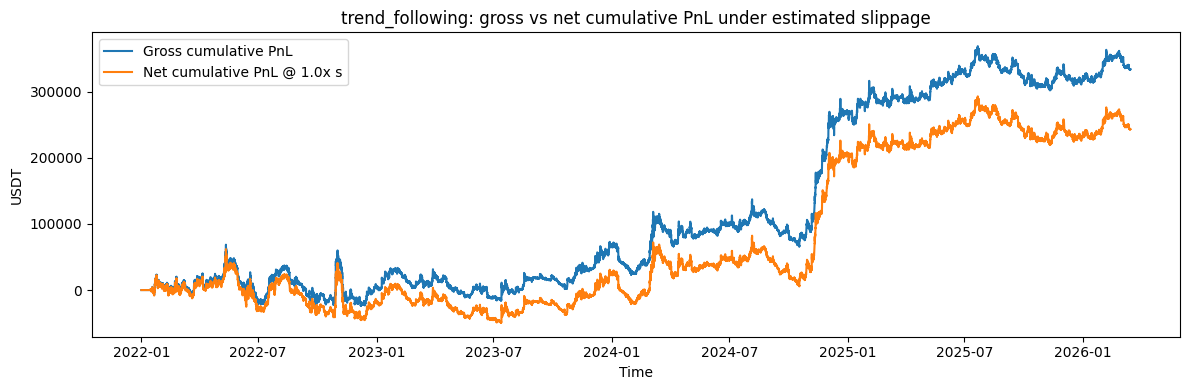

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ============================================================
# Part 3 — Transaction costs / slippage estimation
# ============================================================

# ----------------------------
# User config
# ----------------------------
INTERVAL = "1h"   # should match your Part 1 / Part 2 runs

PART1_DIR = Path("part1_binance_data")
PART2_DIR = Path("part2_strategies")
OUTDIR = Path("part3_transaction_costs")
OUTDIR.mkdir(parents=True, exist_ok=True)

USE_CS_FALLBACK = True
SENSITIVITY_MULTIPLIERS = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
MAKE_PLOTS = True

# Rolling window for diagnostics / robust medians:
# default ~30 calendar days of bars, with reasonable bounds
def interval_to_timedelta(interval: str) -> pd.Timedelta:
    n, unit = int(interval[:-1]), interval[-1]
    if unit == "m":
        return pd.Timedelta(minutes=n)
    if unit == "h":
        return pd.Timedelta(hours=n)
    if unit == "d":
        return pd.Timedelta(days=n)
    if unit == "w":
        return pd.Timedelta(weeks=n)
    raise ValueError(f"Unsupported interval: {interval}")

BAR_DT = interval_to_timedelta(INTERVAL)
ROLL_WINDOW_BARS = int(pd.Timedelta(days=30) / BAR_DT)
ROLL_WINDOW_BARS = max(100, min(5000, ROLL_WINDOW_BARS))

# ----------------------------
# Helpers
# ----------------------------
def load_saved_frame(directory: Path, stem: str, interval: str) -> pd.DataFrame:
    pq = directory / f"{stem}_{interval}.parquet"
    h5 = directory / f"{stem}_{interval}.h5"
    csv = directory / f"{stem}_{interval}.csv"
    if pq.exists():
        df = pd.read_parquet(pq)
    elif h5.exists():
        df = pd.read_hdf(h5, key="data")
    elif csv.exists():
        df = pd.read_csv(csv)
    else:
        raise FileNotFoundError(f"Could not find {pq.name}, {h5.name}, or {csv.name} in {directory}.")
    for c in df.columns:
        if "time" in c.lower() or c.lower() == "date":
            try:
                df[c] = pd.to_datetime(df[c], utc=True)
            except Exception:
                pass
    return df

def safe_save(df: pd.DataFrame, stem: str):
    csv = OUTDIR / f"{stem}.csv"
    df.to_csv(csv, index=False)
    return csv

def weighted_mean(values, weights):
    v = np.asarray(values, dtype=float)
    w = np.asarray(weights, dtype=float)
    mask = np.isfinite(v) & np.isfinite(w) & (w >= 0)
    if mask.sum() == 0:
        return np.nan
    if w[mask].sum() <= 0:
        return np.nanmedian(v[mask])
    return np.average(v[mask], weights=w[mask])

# ----------------------------
# Load Part 1 clean OHLCV
# ----------------------------
if "clean_ohlcv" in globals() and isinstance(clean_ohlcv, pd.DataFrame):
    ohlcv = clean_ohlcv.copy()
else:
    ohlcv = load_saved_frame(PART1_DIR, "clean_ohlcv", INTERVAL)

for c in ["open_time", "close_time"]:
    if c in ohlcv.columns:
        ohlcv[c] = pd.to_datetime(ohlcv[c], utc=True)

for c in ["open", "high", "low", "close", "volume", "quote_volume"]:
    if c in ohlcv.columns:
        ohlcv[c] = pd.to_numeric(ohlcv[c], errors="coerce")

ohlcv = ohlcv.sort_values(["symbol", "open_time"]).reset_index(drop=True)

close_wide = ohlcv.pivot(index="open_time", columns="symbol", values="close").sort_index().astype(float)
high_wide  = ohlcv.pivot(index="open_time", columns="symbol", values="high").sort_index().astype(float)
low_wide   = ohlcv.pivot(index="open_time", columns="symbol", values="low").sort_index().astype(float)

ret_wide = close_wide.pct_change()
symbols = list(close_wide.columns)

# ----------------------------
# Load Part 2 positions
# ----------------------------
if "strategy_positions" in globals() and isinstance(strategy_positions, pd.DataFrame):
    pos_long = strategy_positions.copy()
else:
    pos_long = load_saved_frame(PART2_DIR, "strategy_positions", INTERVAL)

pos_long["open_time"] = pd.to_datetime(pos_long["open_time"], utc=True)
pos_long["theta_usdt"] = pd.to_numeric(pos_long["theta_usdt"], errors="coerce").fillna(0.0)
pos_long = pos_long.sort_values(["strategy", "open_time", "symbol"]).reset_index(drop=True)

strategies = sorted(pos_long["strategy"].dropna().unique().tolist())
if len(strategies) == 0:
    raise ValueError("No strategies found in Part 2 strategy_positions file.")

# restrict to common symbols
symbols = sorted(set(symbols).intersection(set(pos_long["symbol"].unique())))
close_wide = close_wide.reindex(columns=symbols)
high_wide = high_wide.reindex(columns=symbols)
low_wide = low_wide.reindex(columns=symbols)
ret_wide = ret_wide.reindex(columns=symbols)

# ----------------------------
# Step 1 — Asset-level slippage estimation
# ----------------------------
asset_rows = []
slippage_series_long = []

for sym in symbols:
    close = close_wide[sym].astype(float)
    high = high_wide[sym].astype(float)
    low = low_wide[sym].astype(float)

    # -------- Roll model --------
    # Assignment wants s as decimal per trade.
    # Roll gives half-spread in price units:
    #   c = sqrt( -Cov(Δp_t, Δp_{t-1}) )
    # We convert to decimal one-way slippage by dividing by price.
    dp = close.diff()
    cov_full = dp.cov(dp.shift(1))
    c_roll_price_full = np.sqrt(max(-cov_full, 0.0)) if pd.notna(cov_full) else np.nan
    s_roll_full = c_roll_price_full / np.nanmedian(close.values) if np.isfinite(c_roll_price_full) else np.nan

    cov_roll = dp.rolling(ROLL_WINDOW_BARS).cov(dp.shift(1))
    c_roll_price_series = np.sqrt((-cov_roll).clip(lower=0))
    price_norm = close.rolling(ROLL_WINDOW_BARS).median()
    s_roll_series = (c_roll_price_series / price_norm).replace([np.inf, -np.inf], np.nan)

    # robust asset estimate from rolling median, fallback to full-sample Roll
    s_roll_med = np.nanmedian(s_roll_series.values)

    # -------- Corwin-Schultz fallback --------
    # One-way cost = 0.5 * proportional spread
    log_hl = np.log(high / low).replace([np.inf, -np.inf], np.nan)
    beta = log_hl.pow(2) + log_hl.shift(1).pow(2)

    high_2 = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    low_2 = pd.concat([low, low.shift(1)], axis=1).min(axis=1)
    gamma = np.log(high_2 / low_2).pow(2).replace([np.inf, -np.inf], np.nan)

    k = 3 - 2 * np.sqrt(2)
    alpha = ((np.sqrt(2 * beta) - np.sqrt(beta)) / k) - np.sqrt(gamma / k)
    alpha = alpha.clip(lower=0)
    cs_spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))      # proportional round-trip spread
    s_cs_series = 0.5 * cs_spread                                   # one-way decimal per trade
    s_cs_med = np.nanmedian(s_cs_series.values)

    # choose Roll if it works; otherwise fallback
    use_roll = np.isfinite(s_roll_med) and (s_roll_med > 0)
    if use_roll:
        s_hat = float(s_roll_med)
        method = "Roll"
        s_chosen_series = s_roll_series
    else:
        s_hat = float(s_cs_med) if (USE_CS_FALLBACK and np.isfinite(s_cs_med)) else float(np.nan_to_num(s_roll_full, nan=0.0))
        method = "Corwin-Schultz fallback" if (USE_CS_FALLBACK and np.isfinite(s_cs_med)) else "Roll(full-sample fallback)"
        s_chosen_series = s_cs_series if (USE_CS_FALLBACK and np.isfinite(s_cs_med)) else s_roll_series

    avg_quote_vol = float(
        ohlcv.loc[ohlcv["symbol"] == sym, "quote_volume"].mean()
    ) if "quote_volume" in ohlcv.columns else np.nan

    asset_rows.append({
        "symbol": sym,
        "roll_cov_full_price_change": cov_full,
        "roll_half_spread_price_full": c_roll_price_full,
        "roll_slippage_decimal_full": s_roll_full,
        "roll_slippage_decimal_median_rolling": s_roll_med,
        "cs_slippage_decimal_median": s_cs_med,
        "selected_slippage_decimal": s_hat,
        "selected_slippage_bps": 1e4 * s_hat,
        "selected_method": method,
        "median_close": float(np.nanmedian(close.values)),
        "avg_quote_volume": avg_quote_vol,
    })

    tmp = pd.DataFrame({
        "open_time": close.index,
        "symbol": sym,
        "roll_slippage_decimal": s_roll_series.values,
        "cs_slippage_decimal": s_cs_series.values,
        "selected_slippage_decimal": s_chosen_series.values,
    })
    slippage_series_long.append(tmp)

asset_summary = pd.DataFrame(asset_rows).sort_values("selected_slippage_bps").reset_index(drop=True)
slippage_series = pd.concat(slippage_series_long, ignore_index=True).sort_values(["symbol", "open_time"]).reset_index(drop=True)

asset_s = asset_summary.set_index("symbol")["selected_slippage_decimal"].reindex(symbols)

# ----------------------------
# Step 2 — Build turnover and gross PnL per strategy
# Using the Part 4 turnover definition:
#   turnover_t = Σ_i | θ_t^i - θ_{t-1}^i (1 + r_{t-1}^i) |
# ----------------------------
strategy_store = {}
all_trade_by_asset = pd.Series(0.0, index=symbols, dtype=float)

for strat in strategies:
    theta = (
        pos_long.loc[pos_long["strategy"] == strat, ["open_time", "symbol", "theta_usdt"]]
        .pivot(index="open_time", columns="symbol", values="theta_usdt")
        .reindex(ret_wide.index)
        .reindex(columns=symbols)
        .fillna(0.0)
        .astype(float)
    )

    # drift previous positions forward by last bar return
    drifted_prev = theta.shift(1) * (1.0 + ret_wide.shift(1).fillna(0.0))
    trade_abs = (theta - drifted_prev).abs()
    if len(trade_abs) > 0:
        trade_abs.iloc[0] = theta.iloc[0].abs()   # opening trade from cash

    gross_pnl = (theta * ret_wide.fillna(0.0)).sum(axis=1)
    turnover_total = trade_abs.sum(axis=1)

    trade_by_asset = trade_abs.sum(axis=0).reindex(symbols).fillna(0.0)
    all_trade_by_asset = all_trade_by_asset.add(trade_by_asset, fill_value=0.0)

    s_strategy_trade_weighted = weighted_mean(asset_s.values, trade_by_asset.values)

    strategy_store[strat] = {
        "theta": theta,
        "trade_abs": trade_abs,
        "gross_pnl": gross_pnl,
        "turnover_total": turnover_total,
        "trade_by_asset": trade_by_asset,
        "s_trade_weighted": s_strategy_trade_weighted,
    }

# ----------------------------
# Step 3 — Collapse asset-level estimates to a single scalar s
# This is the scalar to use in Part 4.
# Choice: turnover-weighted average across ALL trades from BOTH strategies.
# ----------------------------
s_base = weighted_mean(asset_s.values, all_trade_by_asset.values)
if not np.isfinite(s_base):
    s_base = float(np.nanmedian(asset_s.values))

scalar_rows = [{
    "scope": "global_all_strategies_turnover_weighted",
    "s_decimal": s_base,
    "s_bps": 1e4 * s_base,
}]
for strat in strategies:
    scalar_rows.append({
        "scope": f"{strat}_turnover_weighted",
        "s_decimal": strategy_store[strat]["s_trade_weighted"],
        "s_bps": 1e4 * strategy_store[strat]["s_trade_weighted"],
    })
scalar_rows.append({
    "scope": "cross_asset_median",
    "s_decimal": float(np.nanmedian(asset_s.values)),
    "s_bps": 1e4 * float(np.nanmedian(asset_s.values)),
})
scalar_summary = pd.DataFrame(scalar_rows)

# ----------------------------
# Step 4 — Strategy sensitivity to slippage
# Uses the single scalar s_base to stay compatible with Part 4.
# net_pnl_t(m) = gross_pnl_t - (m * s_base) * turnover_total_t
# ----------------------------
sensitivity_rows = []
sensitivity_ts_rows = []

for strat in strategies:
    gross_pnl = strategy_store[strat]["gross_pnl"]
    turnover_total = strategy_store[strat]["turnover_total"]
    s_trade_weighted = strategy_store[strat]["s_trade_weighted"]

    for mult in SENSITIVITY_MULTIPLIERS:
        s_used = mult * s_base
        cost_t = s_used * turnover_total
        net_pnl_t = gross_pnl - cost_t

        sensitivity_rows.append({
            "strategy": strat,
            "s_multiplier": mult,
            "s_used_decimal": s_used,
            "s_used_bps": 1e4 * s_used,
            "gross_pnl_usdt": float(gross_pnl.sum()),
            "cost_usdt": float(cost_t.sum()),
            "net_pnl_usdt": float(net_pnl_t.sum()),
            "total_turnover_usdt": float(turnover_total.sum()),
            "avg_turnover_per_bar_usdt": float(turnover_total.mean()),
            "strategy_trade_weighted_s_decimal": s_trade_weighted,
            "strategy_trade_weighted_s_bps": 1e4 * s_trade_weighted,
            "cost_as_pct_of_abs_gross_pnl": (
                100.0 * float(cost_t.sum()) / max(abs(float(gross_pnl.sum())), 1e-12)
            ),
        })

        tmp = pd.DataFrame({
            "open_time": gross_pnl.index,
            "strategy": strat,
            "s_multiplier": mult,
            "s_used_decimal": s_used,
            "s_used_bps": 1e4 * s_used,
            "gross_pnl_usdt": gross_pnl.values,
            "turnover_usdt": turnover_total.values,
            "cost_usdt": cost_t.values,
            "net_pnl_usdt": net_pnl_t.values,
            "cum_gross_pnl_usdt": gross_pnl.cumsum().values,
            "cum_net_pnl_usdt": net_pnl_t.cumsum().values,
        })
        sensitivity_ts_rows.append(tmp)

sensitivity_summary = pd.DataFrame(sensitivity_rows).sort_values(["strategy", "s_multiplier"]).reset_index(drop=True)
sensitivity_ts = pd.concat(sensitivity_ts_rows, ignore_index=True)

# ----------------------------
# Save outputs
# ----------------------------
asset_path = safe_save(asset_summary, f"slippage_asset_summary_{INTERVAL}")
scalar_path = safe_save(scalar_summary, f"slippage_scalar_summary_{INTERVAL}")
series_path = safe_save(slippage_series, f"slippage_series_{INTERVAL}")
sens_path = safe_save(sensitivity_summary, f"slippage_sensitivity_summary_{INTERVAL}")
sens_ts_path = safe_save(sensitivity_ts, f"slippage_sensitivity_timeseries_{INTERVAL}")

# ----------------------------
# Display results
# ----------------------------
output_lines = [
    f"Loaded symbols: {', '.join(symbols)}",
    f"Loaded strategies: {', '.join(strategies)}",
    f"Rolling window used for robust slippage medians: {ROLL_WINDOW_BARS} bars",
    "",
    "Chosen scalar slippage for Part 4:",
    f"  s = {s_base:.8f} decimal per trade = {1e4 * s_base:.4f} bps one-way",
    "",
    "Saved:",
    f"  asset summary        -> {asset_path}",
    f"  scalar summary       -> {scalar_path}",
    f"  slippage series      -> {series_path}",
    f"  sensitivity summary  -> {sens_path}",
    f"  sensitivity ts       -> {sens_ts_path}",
    "",
    "Asset-level slippage estimates:",
    "Scalar s summaries:",
    "Strategy sensitivity to slippage:",
]

print("\n".join(output_lines))

display(asset_summary)
display(scalar_summary)
display(sensitivity_summary)

# ----------------------------
# Short interpretation
# ----------------------------
base_rows = sensitivity_summary[sensitivity_summary["s_multiplier"] == 1.0].copy()
if len(base_rows):
    interpretation_lines = ["Interpretation at 1.0x estimated slippage:"]
    print("Interpretation at 1.0x estimated slippage:")
    for _, row in base_rows.iterrows():
        line = (
            f"  {row['strategy']}: gross PnL = {row['gross_pnl_usdt']:.2f} USDT, "
            f"cost drag = {row['cost_usdt']:.2f} USDT, "
            f"net PnL = {row['net_pnl_usdt']:.2f} USDT, "
            f"cost drag = {row['cost_as_pct_of_abs_gross_pnl']:.2f}% of |gross PnL|."
        )
        interpretation_lines.append(line)
        print(line)
    most_sensitive = base_rows.sort_values("cost_usdt", ascending=False).iloc[0]["strategy"]
    interpretation_lines.append(f"  More turnover-intensive strategy under this estimate: {most_sensitive}")
    print(f"  More turnover-intensive strategy under this estimate: {most_sensitive}")
    output_lines.extend([""] + interpretation_lines)

text_path = OUTDIR / f"slippage_run_output_{INTERVAL}.txt"
text_path.write_text("\n".join(output_lines), encoding="utf-8")

# ----------------------------
# Optional plots
# ----------------------------
if MAKE_PLOTS:
    # Plot 1: rolling selected slippage by asset (in bps)
    plt.figure(figsize=(12, 5))
    for sym in symbols:
        s = slippage_series.loc[slippage_series["symbol"] == sym, ["open_time", "selected_slippage_decimal"]].dropna()
        if len(s):
            plt.plot(s["open_time"], 1e4 * s["selected_slippage_decimal"], linewidth=0.9, label=sym)
    plt.title("Rolling selected slippage estimate by asset")
    plt.ylabel("One-way slippage (bps)")
    plt.xlabel("Time")
    plt.legend(ncol=min(3, len(symbols)))
    plt.tight_layout()
    plt.savefig(OUTDIR / f"rolling_selected_slippage_by_asset_{INTERVAL}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Plot 2: net PnL sensitivity curve
    plt.figure(figsize=(10, 4))
    for strat in strategies:
        d = sensitivity_summary[sensitivity_summary["strategy"] == strat]
        plt.plot(d["s_used_bps"], d["net_pnl_usdt"], marker="o", label=strat)
    plt.title("Strategy sensitivity to slippage")
    plt.xlabel("Slippage used (bps, one-way)")
    plt.ylabel("Net PnL (USDT)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTDIR / f"strategy_sensitivity_to_slippage_{INTERVAL}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Plot 3: cumulative gross vs net at 1.0x s for each strategy
    for strat in strategies:
        d = sensitivity_ts[(sensitivity_ts["strategy"] == strat) & (sensitivity_ts["s_multiplier"] == 1.0)].copy()
        if len(d):
            plt.figure(figsize=(12, 4))
            plt.plot(d["open_time"], d["cum_gross_pnl_usdt"], label="Gross cumulative PnL")
            plt.plot(d["open_time"], d["cum_net_pnl_usdt"], label="Net cumulative PnL @ 1.0x s")
            plt.title(f"{strat}: gross vs net cumulative PnL under estimated slippage")
            plt.xlabel("Time")
            plt.ylabel("USDT")
            plt.legend()
            plt.tight_layout()
            plt.savefig(OUTDIR / f"{strat}_gross_vs_net_cumulative_pnl_{INTERVAL}.png", dpi=300, bbox_inches="tight")
            plt.show()

Loaded strategies: mean_reversion, trend_following
Loaded symbols   : ADAUSDT, BNBUSDT, BTCUSDT, DOGEUSDT, ETHUSDT, XRPUSDT
Bar interval     : 1h
Initial capital  : 10,000 USDT
Gross cap        : 100,000 USDT
Slippage used    : s = 0.00086777 decimal per trade = 8.6777 bps
Slippage source  : in_memory_s_base

Saved:
  summary         -> part4_performance/performance_summary_1h.csv
  ts              -> part4_performance/performance_timeseries_1h.csv
  positions       -> part4_performance/performance_effective_positions_1h.csv
  holding         -> part4_performance/performance_holding_asset_1h.csv
  primary_summary -> part4_performance/performance_primary_mode_summary_1h.csv

Primary-mode summary:


,strategy,exposure_mode,net_total_pnl_usdt,net_return_pct_on_initial,total_cost_usdt,total_turnover_usdt,avg_holding_horizon_bars,avg_holding_horizon_days,sharpe_net,sortino_net,calmar_net,max_drawdown_net_pct,logic_description
0,mean_reversion,fixed_100k_cap,-354508.910917,-3545.089109,212658.244822,2.450632e+08,29.424209,1.226009,-3.259885,-4.323125,-17.794337,2486.005396,Use Part 2 notionals directly. Profits/losses ...
1,trend_following,fixed_100k_cap,243432.379659,2434.323797,90420.643119,1.041990e+08,70.048393,2.918683,-0.115591,-0.121665,0.746271,155.070006,Use Part 2 notionals directly. Profits/losses ...


All-mode summary:


,strategy,exposure_mode,logic_description,s_decimal,s_bps,initial_capital_usdt,absolute_gross_cap_usdt,gross_total_pnl_usdt,net_total_pnl_usdt,total_cost_usdt,...,annualized_return_net,sharpe_gross,sharpe_net,sortino_gross,sortino_net,calmar_gross,calmar_net,max_drawdown_gross_pct,max_drawdown_net_pct,first_nonpositive_net_equity_time
0,mean_reversion,equity_protected_cap,"Scale Part 2 notionals each bar by min(1, 10 ×...",0.000868,8.67769,10000.0,100000.0,-8650.393115,-10000.000000,1349.606885,...,-9.303405,-0.539214,-1.556084,-0.656696,-2.045301,-0.413827,-9.303405,91.572449,100.000000,2022-10-29 08:00:00+00:00
1,mean_reversion,fixed_100k_cap,Use Part 2 notionals directly. Profits/losses ...,0.000868,8.67769,10000.0,100000.0,-141850.666095,-354508.910917,212658.244822,...,-442.368171,1.755859,-3.259885,10.915452,-4.323125,17.565566,-17.794337,771.009533,2486.005396,2022-01-14 06:00:00+00:00
2,trend_following,equity_protected_cap,"Scale Part 2 notionals each bar by min(1, 10 ×...",0.000868,8.67769,10000.0,100000.0,-7429.318279,-10001.357797,2572.039517,...,8.163033,0.108786,0.944519,0.163133,1.390401,-0.303164,8.162634,91.069734,100.004890,2022-05-11 13:00:00+00:00
3,trend_following,fixed_100k_cap,Use Part 2 notionals directly. Profits/losses ...,0.000868,8.67769,10000.0,100000.0,333853.022778,243432.379659,90420.643119,...,1.157242,0.741087,-0.115591,2.299432,-0.121665,1.123068,0.746271,117.500836,155.070006,2022-03-20 11:00:00+00:00


Asset-level holding horizon estimate:


,strategy,exposure_mode,symbol,avg_abs_theta_usdt,avg_turnover_per_bar_usdt,approx_holding_horizon_bars,approx_holding_horizon_days
0,mean_reversion,equity_protected_cap,ADAUSDT,75.683025,8.132987,18.611373,0.775474
1,mean_reversion,equity_protected_cap,BNBUSDT,66.759040,6.870030,19.434861,0.809786
2,mean_reversion,equity_protected_cap,BTCUSDT,111.819981,7.794556,28.691817,1.195492
3,mean_reversion,equity_protected_cap,DOGEUSDT,87.994929,11.904134,14.783927,0.615997
4,mean_reversion,equity_protected_cap,ETHUSDT,36.952964,3.594169,20.562728,0.856780
5,mean_reversion,equity_protected_cap,XRPUSDT,44.725725,3.929920,22.761646,0.948402
6,mean_reversion,fixed_100k_cap,ADAUSDT,17359.789812,1199.684545,28.940591,1.205858
7,mean_reversion,fixed_100k_cap,BNBUSDT,17115.319825,1081.994613,31.636608,1.318192
8,mean_reversion,fixed_100k_cap,BTCUSDT,11516.968283,837.803599,27.493241,1.145552
9,mean_reversion,fixed_100k_cap,DOGEUSDT,19673.147928,1352.752166,29.086108,1.211921


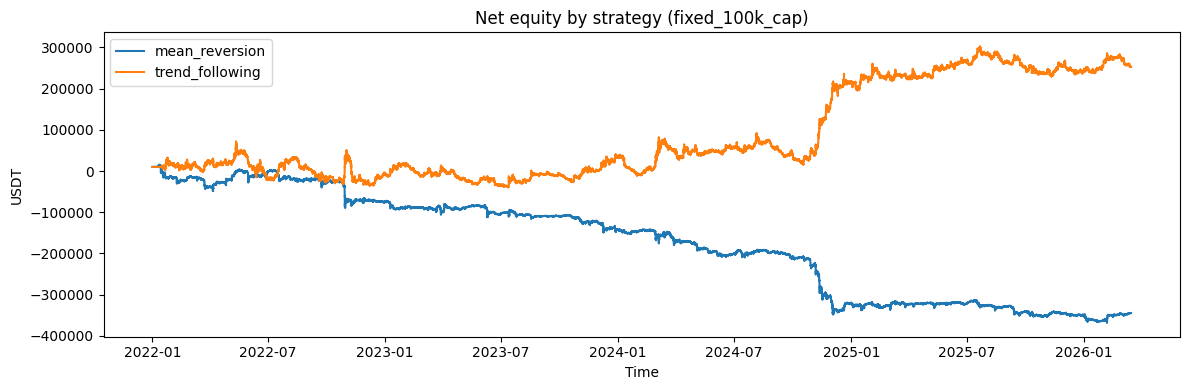

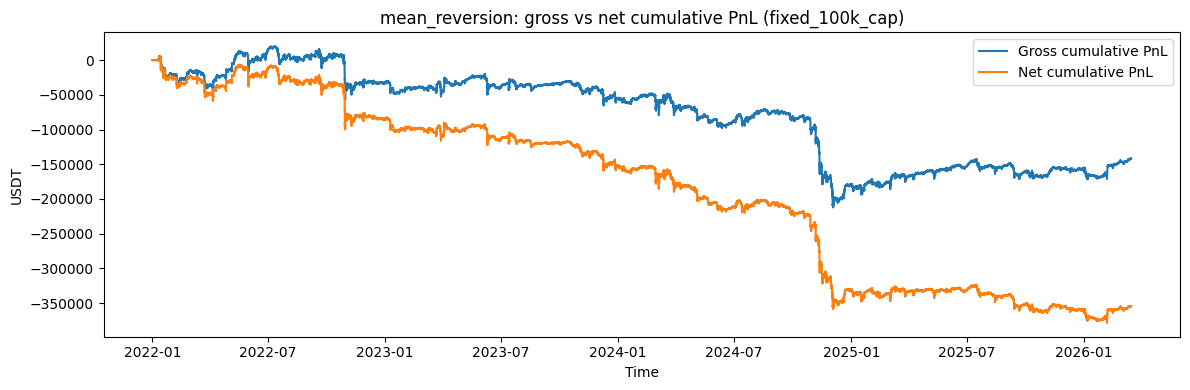

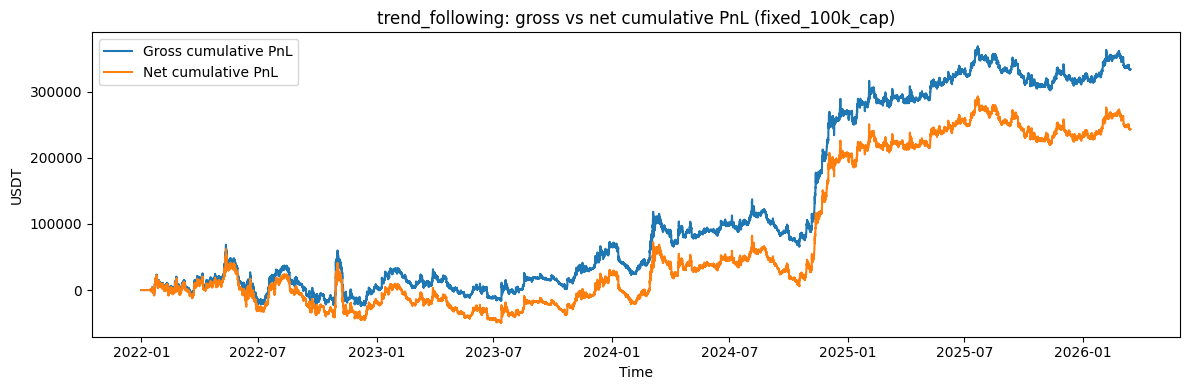

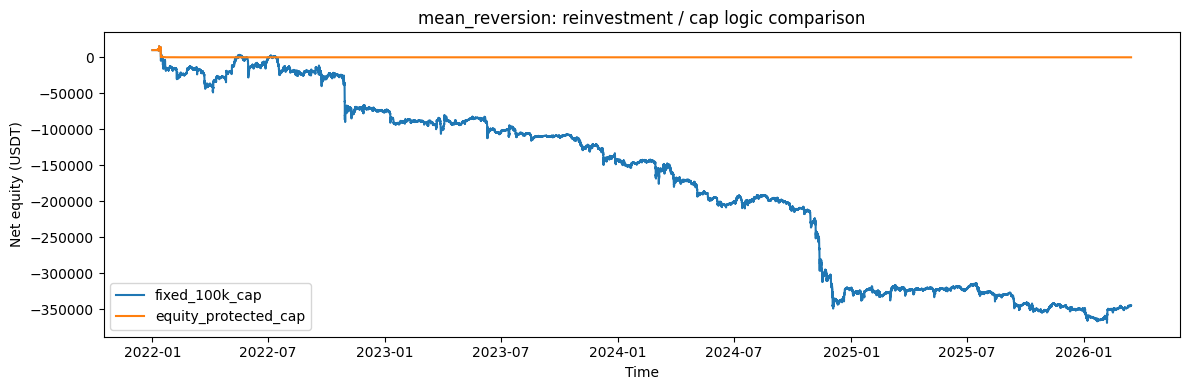

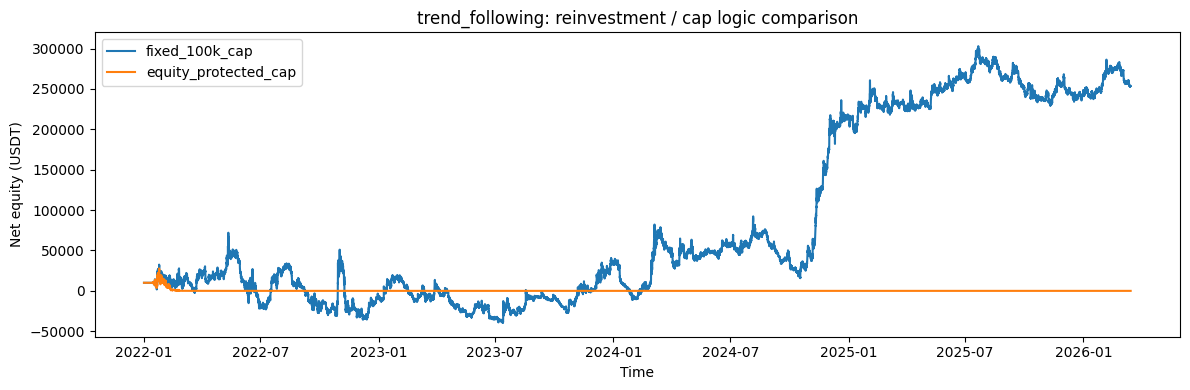

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ============================================================
# Part 4 — Performance with market returns + rebalancing costs
# ============================================================

# ----------------------------
# User config
# ----------------------------
INTERVAL = "1h"
INITIAL_CAPITAL = 10_000.0
ABSOLUTE_GROSS_CAP = 100_000.0
LEVERAGE_LIMIT = 10.0

PART1_DIR = Path("part1_binance_data")
PART2_DIR = Path("part2_strategies")
PART3_DIR = Path("part3_transaction_costs")
OUTDIR = Path("part4_performance")
OUTDIR.mkdir(parents=True, exist_ok=True)

EXPOSURE_MODES = ["fixed_100k_cap", "equity_protected_cap"]
PRIMARY_MODE = "fixed_100k_cap"  # main interpretation to emphasize in plots/tables

SLIPPAGE_SCOPE = "global_all_strategies_turnover_weighted"  # from Part 3
MAKE_PLOTS = True

# ----------------------------
# Helpers
# ----------------------------
def interval_to_timedelta(interval: str) -> pd.Timedelta:
    n, unit = int(interval[:-1]), interval[-1]
    if unit == "m":
        return pd.Timedelta(minutes=n)
    if unit == "h":
        return pd.Timedelta(hours=n)
    if unit == "d":
        return pd.Timedelta(days=n)
    if unit == "w":
        return pd.Timedelta(weeks=n)
    raise ValueError(f"Unsupported interval: {interval}")

BAR_DT = interval_to_timedelta(INTERVAL)
BARS_PER_YEAR = float(pd.Timedelta(days=365) / BAR_DT)

def load_saved_frame(directory: Path, stem: str, interval: str) -> pd.DataFrame:
    pq = directory / f"{stem}_{interval}.parquet"
    h5 = directory / f"{stem}_{interval}.h5"
    csv = directory / f"{stem}_{interval}.csv"
    if pq.exists():
        df = pd.read_parquet(pq)
    elif h5.exists():
        df = pd.read_hdf(h5, key="data")
    elif csv.exists():
        df = pd.read_csv(csv)
    else:
        raise FileNotFoundError(f"Could not find {pq.name}, {h5.name}, or {csv.name} in {directory}.")
    for c in df.columns:
        if "time" in c.lower() or c.lower() == "date":
            try:
                df[c] = pd.to_datetime(df[c], utc=True)
            except Exception:
                pass
    return df

def safe_save(df: pd.DataFrame, stem: str):
    csv = OUTDIR / f"{stem}.csv"
    df.to_csv(csv, index=False)
    return csv

def sharpe_ratio(ret: pd.Series, bars_per_year: float) -> float:
    r = pd.Series(ret).dropna().astype(float)
    if len(r) < 2:
        return np.nan
    sd = float(r.std(ddof=0))
    if not np.isfinite(sd) or sd == 0:
        return np.nan
    return np.sqrt(bars_per_year) * float(r.mean()) / sd

def sortino_ratio(ret: pd.Series, bars_per_year: float) -> float:
    r = pd.Series(ret).dropna().astype(float)
    if len(r) < 2:
        return np.nan
    downside = np.minimum(r.values, 0.0)
    downside_dev = np.sqrt(np.mean(downside**2))
    if not np.isfinite(downside_dev) or downside_dev == 0:
        return np.nan
    return np.sqrt(bars_per_year) * float(r.mean()) / downside_dev

def max_drawdown(equity: pd.Series):
    eq = pd.Series(equity).astype(float)
    running_max = eq.cummax()
    dd = eq / running_max - 1.0
    mdd = float(-dd.min()) if len(dd) else np.nan
    return mdd, dd

def annualized_return(initial_capital: float, end_equity: float, n_bars: int, bars_per_year: float, fallback_mean_ret: float = np.nan) -> float:
    if n_bars <= 0:
        return np.nan
    years = n_bars / bars_per_year
    if initial_capital > 0 and end_equity > 0 and years > 0:
        return (end_equity / initial_capital) ** (1.0 / years) - 1.0
    if np.isfinite(fallback_mean_ret):
        return fallback_mean_ret * bars_per_year
    return np.nan

def calmar_ratio(initial_capital: float, equity: pd.Series, ret: pd.Series, bars_per_year: float):
    mdd, dd = max_drawdown(equity)
    ann_ret = annualized_return(
        initial_capital=initial_capital,
        end_equity=float(pd.Series(equity).iloc[-1]),
        n_bars=max(len(pd.Series(equity)) - 1, 1),
        bars_per_year=bars_per_year,
        fallback_mean_ret=float(pd.Series(ret).dropna().mean()) if len(pd.Series(ret).dropna()) else np.nan,
    )
    if not np.isfinite(mdd) or mdd <= 0:
        return np.nan, ann_ret, dd
    return ann_ret / mdd, ann_ret, dd

def approx_holding_horizon(avg_gross_exposure: float, avg_turnover_per_bar: float, bar_dt: pd.Timedelta):
    # With turnover measured as Σ|Δθ|, a rough round-trip holding period is:
    # H ≈ 2 * average gross exposure / average turnover per bar
    if not np.isfinite(avg_turnover_per_bar) or avg_turnover_per_bar <= 0:
        return np.nan, np.nan
    bars = 2.0 * avg_gross_exposure / avg_turnover_per_bar
    days = bars * (bar_dt / pd.Timedelta(days=1))
    return float(bars), float(days)

def choose_slippage_scalar():
    # Prefer in-memory value from Part 3 if available
    if "s_base" in globals():
        try:
            val = float(s_base)
            if np.isfinite(val) and val >= 0:
                return val, "in_memory_s_base"
        except Exception:
            pass

    # Otherwise use saved Part 3 scalar summary
    if "scalar_summary" in globals() and isinstance(scalar_summary, pd.DataFrame):
        ss = scalar_summary.copy()
    else:
        ss = load_saved_frame(PART3_DIR, "slippage_scalar_summary", INTERVAL)

    if "scope" in ss.columns and "s_decimal" in ss.columns:
        hit = ss.loc[ss["scope"] == SLIPPAGE_SCOPE, "s_decimal"]
        if len(hit):
            val = float(pd.to_numeric(hit, errors="coerce").iloc[0])
            if np.isfinite(val) and val >= 0:
                return val, SLIPPAGE_SCOPE

        hit = ss["s_decimal"].dropna()
        if len(hit):
            val = float(pd.to_numeric(hit, errors="coerce").iloc[0])
            if np.isfinite(val) and val >= 0:
                return val, "first_available_scope"

    raise ValueError("Could not determine slippage scalar s from Part 3.")

def run_performance(theta_base: pd.DataFrame, returns: pd.DataFrame, strategy_name: str, s_decimal: float, exposure_mode: str):
    theta_base = theta_base.reindex(index=returns.index, columns=returns.columns).fillna(0.0).astype(float)
    base_gross = theta_base.abs().sum(axis=1)
    if float(base_gross.max()) > ABSOLUTE_GROSS_CAP + 1e-6:
        raise ValueError(f"Part 2 base positions violate the $100k gross cap for strategy {strategy_name}.")

    idx = returns.index
    cols = returns.columns
    T, N = returns.shape

    theta_eff = np.zeros((T, N), dtype=float)
    trade_abs = np.zeros((T, N), dtype=float)
    gross_limit_arr = np.zeros(T, dtype=float)
    gross_exposure_arr = np.zeros(T, dtype=float)
    net_exposure_arr = np.zeros(T, dtype=float)
    unused_gross_capacity_arr = np.zeros(T, dtype=float)
    turnover_arr = np.zeros(T, dtype=float)
    cost_arr = np.zeros(T, dtype=float)
    gross_pnl_arr = np.zeros(T, dtype=float)
    net_pnl_arr = np.zeros(T, dtype=float)
    equity_gross_arr = np.zeros(T, dtype=float)
    equity_net_arr = np.zeros(T, dtype=float)

    theta_prev = np.zeros(N, dtype=float)
    r_prev = np.zeros(N, dtype=float)
    eq_gross_prev = INITIAL_CAPITAL
    eq_net_prev = INITIAL_CAPITAL

    if exposure_mode == "fixed_100k_cap":
        logic_text = (
            "Use Part 2 notionals directly. Profits/losses remain in equity (cash), "
            "but target notionals are not rescaled after gains/losses. Absolute gross cap stays $100k."
        )
    elif exposure_mode == "equity_protected_cap":
        logic_text = (
            "Scale Part 2 notionals each bar by min(1, 10 × lagged net equity / 100000). "
            "This scales down after losses to keep leverage near 10x current equity, "
            "but never scales above the $100k absolute cap."
        )
    else:
        raise ValueError(f"Unknown exposure_mode: {exposure_mode}")

    for t, ts in enumerate(idx):
        r_t = np.nan_to_num(returns.iloc[t].values.astype(float), nan=0.0)

        # Choose gross limit / scaling for this bar using lagged net equity
        if exposure_mode == "fixed_100k_cap":
            gross_limit_t = ABSOLUTE_GROSS_CAP
            scale_t = 1.0
        else:
            gross_limit_t = min(ABSOLUTE_GROSS_CAP, LEVERAGE_LIMIT * max(eq_net_prev, 0.0))
            scale_t = gross_limit_t / ABSOLUTE_GROSS_CAP if ABSOLUTE_GROSS_CAP > 0 else 0.0

        target_theta = theta_base.iloc[t].values.astype(float) * scale_t

        # Safety re-projection in case of numerical drift
        gross_now = np.sum(np.abs(target_theta))
        if gross_now > gross_limit_t and gross_now > 0:
            target_theta *= gross_limit_t / gross_now
            gross_now = gross_limit_t

        drifted_prev = theta_prev * (1.0 + r_prev)
        trade_t = np.abs(target_theta - drifted_prev)
        turnover_t = float(np.sum(trade_t))
        cost_t = float(s_decimal * turnover_t)

        gross_pnl_t = float(np.sum(target_theta * r_t))
        net_pnl_t = gross_pnl_t - cost_t

        eq_gross_prev = eq_gross_prev + gross_pnl_t
        eq_net_prev = eq_net_prev + net_pnl_t

        theta_eff[t, :] = target_theta
        trade_abs[t, :] = trade_t
        gross_limit_arr[t] = gross_limit_t
        gross_exposure_arr[t] = float(np.sum(np.abs(target_theta)))
        net_exposure_arr[t] = float(np.sum(target_theta))
        unused_gross_capacity_arr[t] = float(gross_limit_t - gross_exposure_arr[t])
        turnover_arr[t] = turnover_t
        cost_arr[t] = cost_t
        gross_pnl_arr[t] = gross_pnl_t
        net_pnl_arr[t] = net_pnl_t
        equity_gross_arr[t] = eq_gross_prev
        equity_net_arr[t] = eq_net_prev

        theta_prev = target_theta.copy()
        r_prev = r_t.copy()

    theta_eff_df = pd.DataFrame(theta_eff, index=idx, columns=cols)
    trade_abs_df = pd.DataFrame(trade_abs, index=idx, columns=cols)

    ts_df = pd.DataFrame({
        "open_time": idx,
        "strategy": strategy_name,
        "exposure_mode": exposure_mode,
        "gross_limit_usdt": gross_limit_arr,
        "gross_exposure_usdt": gross_exposure_arr,
        "net_exposure_usdt": net_exposure_arr,
        "unused_gross_capacity_usdt": unused_gross_capacity_arr,
        "turnover_usdt": turnover_arr,
        "cost_usdt": cost_arr,
        "gross_pnl_usdt": gross_pnl_arr,
        "net_pnl_usdt": net_pnl_arr,
        "equity_gross_usdt": equity_gross_arr,
        "equity_net_usdt": equity_net_arr,
    }).set_index("open_time")

    lag_eq_gross = ts_df["equity_gross_usdt"].shift(1).fillna(INITIAL_CAPITAL)
    lag_eq_net = ts_df["equity_net_usdt"].shift(1).fillna(INITIAL_CAPITAL)

    ts_df["gross_return_on_initial_capital"] = ts_df["gross_pnl_usdt"] / INITIAL_CAPITAL
    ts_df["net_return_on_initial_capital"] = ts_df["net_pnl_usdt"] / INITIAL_CAPITAL

    ts_df["gross_portfolio_return"] = np.where(lag_eq_gross > 0, ts_df["gross_pnl_usdt"] / lag_eq_gross, np.nan)
    ts_df["net_portfolio_return"] = np.where(lag_eq_net > 0, ts_df["net_pnl_usdt"] / lag_eq_net, np.nan)

    ts_df["cum_gross_pnl_usdt"] = ts_df["gross_pnl_usdt"].cumsum()
    ts_df["cum_net_pnl_usdt"] = ts_df["net_pnl_usdt"].cumsum()
    ts_df["cum_gross_return_pct_on_initial"] = 100.0 * (ts_df["equity_gross_usdt"] / INITIAL_CAPITAL - 1.0)
    ts_df["cum_net_return_pct_on_initial"] = 100.0 * (ts_df["equity_net_usdt"] / INITIAL_CAPITAL - 1.0)

    mdd_gross, dd_gross = max_drawdown(ts_df["equity_gross_usdt"])
    mdd_net, dd_net = max_drawdown(ts_df["equity_net_usdt"])
    ts_df["drawdown_gross"] = dd_gross.values
    ts_df["drawdown_net"] = dd_net.values

    gross_ret = ts_df["gross_portfolio_return"]
    net_ret = ts_df["net_portfolio_return"]

    sharpe_gross = sharpe_ratio(gross_ret, BARS_PER_YEAR)
    sharpe_net = sharpe_ratio(net_ret, BARS_PER_YEAR)
    sortino_gross = sortino_ratio(gross_ret, BARS_PER_YEAR)
    sortino_net = sortino_ratio(net_ret, BARS_PER_YEAR)
    calmar_gross, ann_gross, _ = calmar_ratio(INITIAL_CAPITAL, ts_df["equity_gross_usdt"], gross_ret, BARS_PER_YEAR)
    calmar_net, ann_net, _ = calmar_ratio(INITIAL_CAPITAL, ts_df["equity_net_usdt"], net_ret, BARS_PER_YEAR)

    avg_gross_exposure = float(ts_df["gross_exposure_usdt"].mean())
    avg_turnover_per_bar = float(ts_df["turnover_usdt"].mean())
    hold_bars, hold_days = approx_holding_horizon(avg_gross_exposure, avg_turnover_per_bar, BAR_DT)

    holding_asset = pd.DataFrame({
        "strategy": strategy_name,
        "exposure_mode": exposure_mode,
        "symbol": cols,
        "avg_abs_theta_usdt": theta_eff_df.abs().mean().values,
        "avg_turnover_per_bar_usdt": trade_abs_df.mean().values,
    })
    holding_asset["approx_holding_horizon_bars"] = np.where(
        holding_asset["avg_turnover_per_bar_usdt"] > 0,
        2.0 * holding_asset["avg_abs_theta_usdt"] / holding_asset["avg_turnover_per_bar_usdt"],
        np.nan
    )
    holding_asset["approx_holding_horizon_days"] = holding_asset["approx_holding_horizon_bars"] * (BAR_DT / pd.Timedelta(days=1))

    nonpos_idx = ts_df.index[ts_df["equity_net_usdt"] <= 0]
    first_nonpos = nonpos_idx.min() if len(nonpos_idx) else pd.NaT

    summary_row = {
        "strategy": strategy_name,
        "exposure_mode": exposure_mode,
        "logic_description": logic_text,
        "s_decimal": float(s_decimal),
        "s_bps": 1e4 * float(s_decimal),
        "initial_capital_usdt": INITIAL_CAPITAL,
        "absolute_gross_cap_usdt": ABSOLUTE_GROSS_CAP,
        "gross_total_pnl_usdt": float(ts_df["gross_pnl_usdt"].sum()),
        "net_total_pnl_usdt": float(ts_df["net_pnl_usdt"].sum()),
        "total_cost_usdt": float(ts_df["cost_usdt"].sum()),
        "gross_end_equity_usdt": float(ts_df["equity_gross_usdt"].iloc[-1]),
        "net_end_equity_usdt": float(ts_df["equity_net_usdt"].iloc[-1]),
        "gross_return_pct_on_initial": 100.0 * (float(ts_df["equity_gross_usdt"].iloc[-1]) / INITIAL_CAPITAL - 1.0),
        "net_return_pct_on_initial": 100.0 * (float(ts_df["equity_net_usdt"].iloc[-1]) / INITIAL_CAPITAL - 1.0),
        "total_turnover_usdt": float(ts_df["turnover_usdt"].sum()),
        "avg_turnover_per_bar_usdt": avg_turnover_per_bar,
        "avg_gross_exposure_usdt": avg_gross_exposure,
        "avg_abs_net_exposure_usdt": float(ts_df["net_exposure_usdt"].abs().mean()),
        "avg_unused_gross_capacity_usdt": float(ts_df["unused_gross_capacity_usdt"].mean()),
        "avg_holding_horizon_bars": hold_bars,
        "avg_holding_horizon_days": hold_days,
        "annualized_return_gross": float(ann_gross) if np.isfinite(ann_gross) else np.nan,
        "annualized_return_net": float(ann_net) if np.isfinite(ann_net) else np.nan,
        "sharpe_gross": float(sharpe_gross) if np.isfinite(sharpe_gross) else np.nan,
        "sharpe_net": float(sharpe_net) if np.isfinite(sharpe_net) else np.nan,
        "sortino_gross": float(sortino_gross) if np.isfinite(sortino_gross) else np.nan,
        "sortino_net": float(sortino_net) if np.isfinite(sortino_net) else np.nan,
        "calmar_gross": float(calmar_gross) if np.isfinite(calmar_gross) else np.nan,
        "calmar_net": float(calmar_net) if np.isfinite(calmar_net) else np.nan,
        "max_drawdown_gross_pct": 100.0 * float(mdd_gross) if np.isfinite(mdd_gross) else np.nan,
        "max_drawdown_net_pct": 100.0 * float(mdd_net) if np.isfinite(mdd_net) else np.nan,
        "first_nonpositive_net_equity_time": first_nonpos,
    }

    return {
        "summary_row": summary_row,
        "timeseries": ts_df,
        "theta_effective": theta_eff_df,
        "trade_abs": trade_abs_df,
        "holding_asset": holding_asset,
    }

# ----------------------------
# Load inputs from Parts 1–3
# ----------------------------
if "clean_ohlcv" in globals() and isinstance(clean_ohlcv, pd.DataFrame):
    clean_df = clean_ohlcv.copy()
else:
    clean_df = load_saved_frame(PART1_DIR, "clean_ohlcv", INTERVAL)

if "strategy_positions" in globals() and isinstance(strategy_positions, pd.DataFrame):
    pos_long = strategy_positions.copy()
else:
    pos_long = load_saved_frame(PART2_DIR, "strategy_positions", INTERVAL)

s_used, s_source = choose_slippage_scalar()

for c in ["open_time", "close_time"]:
    if c in clean_df.columns:
        clean_df[c] = pd.to_datetime(clean_df[c], utc=True)
pos_long["open_time"] = pd.to_datetime(pos_long["open_time"], utc=True)

for c in ["close"]:
    if c in clean_df.columns:
        clean_df[c] = pd.to_numeric(clean_df[c], errors="coerce")
pos_long["theta_usdt"] = pd.to_numeric(pos_long["theta_usdt"], errors="coerce").fillna(0.0)

# Build market returns r_t^i from cleaned close prices
close_wide = (
    clean_df.pivot(index="open_time", columns="symbol", values="close")
    .sort_index()
    .astype(float)
    .ffill()
)
ret_wide = close_wide.pct_change().fillna(0.0)

# Intersect symbols used in prices and strategies
symbols = sorted(set(ret_wide.columns).intersection(set(pos_long["symbol"].dropna().unique())))
if len(symbols) == 0:
    raise ValueError("No common symbols found between Part 1 prices and Part 2 positions.")
ret_wide = ret_wide.reindex(columns=symbols)

strategies = sorted(pos_long["strategy"].dropna().unique().tolist())
if len(strategies) == 0:
    raise ValueError("No strategies found in Part 2 positions.")

# ----------------------------
# Run performance for every strategy and exposure mode
# ----------------------------
summary_rows = []
ts_long = []
theta_long = []
holding_asset_rows = []

for strat in strategies:
    theta_base = (
        pos_long.loc[pos_long["strategy"] == strat, ["open_time", "symbol", "theta_usdt"]]
        .pivot(index="open_time", columns="symbol", values="theta_usdt")
        .reindex(index=ret_wide.index, columns=symbols)
        .fillna(0.0)
        .astype(float)
    )

    for mode in EXPOSURE_MODES:
        out = run_performance(
            theta_base=theta_base,
            returns=ret_wide,
            strategy_name=strat,
            s_decimal=s_used,
            exposure_mode=mode,
        )

        summary_rows.append(out["summary_row"])

        tmp_ts = out["timeseries"].reset_index()
        ts_long.append(tmp_ts)

        tmp_theta = out["theta_effective"].stack().rename("theta_effective_usdt").reset_index()
        tmp_theta.columns = ["open_time", "symbol", "theta_effective_usdt"]
        tmp_theta["strategy"] = strat
        tmp_theta["exposure_mode"] = mode
        tmp_theta["weight_on_absolute_gross_cap"] = tmp_theta["theta_effective_usdt"] / ABSOLUTE_GROSS_CAP
        theta_long.append(tmp_theta[["strategy", "exposure_mode", "open_time", "symbol", "theta_effective_usdt", "weight_on_absolute_gross_cap"]])

        holding_asset_rows.append(out["holding_asset"])

summary_df = pd.DataFrame(summary_rows).sort_values(["strategy", "exposure_mode"]).reset_index(drop=True)
performance_ts = pd.concat(ts_long, ignore_index=True).sort_values(["strategy", "exposure_mode", "open_time"]).reset_index(drop=True)
effective_positions = pd.concat(theta_long, ignore_index=True).sort_values(["strategy", "exposure_mode", "open_time", "symbol"]).reset_index(drop=True)
holding_asset_df = pd.concat(holding_asset_rows, ignore_index=True).sort_values(["strategy", "exposure_mode", "symbol"]).reset_index(drop=True)

primary_mode_summary = (
    summary_df.loc[summary_df["exposure_mode"] == PRIMARY_MODE, [
        "strategy", "exposure_mode", "net_total_pnl_usdt", "net_return_pct_on_initial",
        "total_cost_usdt", "total_turnover_usdt", "avg_holding_horizon_bars",
        "avg_holding_horizon_days", "sharpe_net", "sortino_net", "calmar_net",
        "max_drawdown_net_pct", "logic_description"
    ]]
    .sort_values("strategy")
    .reset_index(drop=True)
)

# ----------------------------
# Save outputs
# ----------------------------
summary_path = safe_save(summary_df, f"performance_summary_{INTERVAL}")
ts_path = safe_save(performance_ts, f"performance_timeseries_{INTERVAL}")
theta_path = safe_save(effective_positions, f"performance_effective_positions_{INTERVAL}")
holding_path = safe_save(holding_asset_df, f"performance_holding_asset_{INTERVAL}")
primary_summary_path = safe_save(primary_mode_summary, f"performance_primary_mode_summary_{INTERVAL}")

# ----------------------------
# Display key outputs
# ----------------------------
output_text = "\n".join([
    f"Loaded strategies: {', '.join(strategies)}",
    f"Loaded symbols   : {', '.join(symbols)}",
    f"Bar interval     : {INTERVAL}",
    f"Initial capital  : {INITIAL_CAPITAL:,.0f} USDT",
    f"Gross cap        : {ABSOLUTE_GROSS_CAP:,.0f} USDT",
    f"Slippage used    : s = {s_used:.8f} decimal per trade = {1e4 * s_used:.4f} bps",
    f"Slippage source  : {s_source}",
    "",
    "Saved:",
    f"  summary         -> {summary_path}",
    f"  ts              -> {ts_path}",
    f"  positions       -> {theta_path}",
    f"  holding         -> {holding_path}",
    f"  primary_summary -> {primary_summary_path}",
])

print(output_text)

text_output_path = OUTDIR / f"performance_run_output_{INTERVAL}.txt"
text_output_path.write_text(output_text, encoding="utf-8")

print("")
print("Primary-mode summary:")
display(primary_mode_summary)

print("All-mode summary:")
display(summary_df)

print("Asset-level holding horizon estimate:")
display(holding_asset_df)

# ----------------------------
# Optional plots
# ----------------------------
if MAKE_PLOTS:
    # 1) Net equity under the primary mode
    plt.figure(figsize=(12, 4))
    for strat in strategies:
        d = performance_ts[
            (performance_ts["strategy"] == strat) &
            (performance_ts["exposure_mode"] == PRIMARY_MODE)
        ].copy()
        plt.plot(pd.to_datetime(d["open_time"], utc=True), d["equity_net_usdt"], label=strat)
    plt.title(f"Net equity by strategy ({PRIMARY_MODE})")
    plt.xlabel("Time")
    plt.ylabel("USDT")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTDIR / f"net_equity_by_strategy_{PRIMARY_MODE}_{INTERVAL}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 2) Gross vs net cumulative PnL for each strategy under primary mode
    for strat in strategies:
        d = performance_ts[
            (performance_ts["strategy"] == strat) &
            (performance_ts["exposure_mode"] == PRIMARY_MODE)
        ].copy()
        plt.figure(figsize=(12, 4))
        plt.plot(pd.to_datetime(d["open_time"], utc=True), d["cum_gross_pnl_usdt"], label="Gross cumulative PnL")
        plt.plot(pd.to_datetime(d["open_time"], utc=True), d["cum_net_pnl_usdt"], label="Net cumulative PnL")
        plt.title(f"{strat}: gross vs net cumulative PnL ({PRIMARY_MODE})")
        plt.xlabel("Time")
        plt.ylabel("USDT")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTDIR / f"{strat}_gross_vs_net_cumulative_pnl_{PRIMARY_MODE}_{INTERVAL}.png", dpi=300, bbox_inches="tight")
        plt.show()

    # 3) Fixed cap vs equity-protected cap comparison
    for strat in strategies:
        plt.figure(figsize=(12, 4))
        for mode in EXPOSURE_MODES:
            d = performance_ts[
                (performance_ts["strategy"] == strat) &
                (performance_ts["exposure_mode"] == mode)
            ].copy()
            plt.plot(pd.to_datetime(d["open_time"], utc=True), d["equity_net_usdt"], label=mode)
        plt.title(f"{strat}: reinvestment / cap logic comparison")
        plt.xlabel("Time")
        plt.ylabel("Net equity (USDT)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTDIR / f"{strat}_reinvestment_cap_logic_comparison_{INTERVAL}.png", dpi=300, bbox_inches="tight")
        plt.show()